# Bank Management System — Data Mining & EDA Report

---

| Field | Detail |
|-------|--------|
| **Course** | Data Mining & Visualization |
| **Project Topic** | Topic 7 — Bank Management System |
| **Part** | Part 2 — Data Analyst Report (Appendix B) |
| **Dataset** | `full_data_noisy.csv` — Bank transactions with customer, account, employee and service data |
| **Due Date** | 14-3-2026 |

---

## Project Structure

| Section | Description |
|---------|-------------|
| **A — Dataset Overview** | Shape, sample rows, column meanings, type checks |
| **B — Data Quality** | Missing values, duplicates, validity rules, category cleanliness |
| **C — Univariate EDA** | Numeric summaries, distributions, outliers, categorical frequencies |
| **D — Relationships** | Correlations, scatter plots, category–numeric effects, heatmap |
| **E — Final Summary** | Top insights, top risks, next steps |
| **Bonus** | Machine Learning — Random Forest classifier for Service_Status |

---
# Section A — Dataset Overview + Types

## Q1 — Dataset Overview & Setup
> Report dataset shape, show sample rows, list column names, and load libraries.

In [1]:
# --- 1. Setup and Data Loading ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Data_Mining_Noisy_File.csv')
df_clean = df.copy()

print("Data loaded successfully.")
print(f"Dataset shape: {df.shape}")
df.head()

Saving Data_Mining_Noisy_File.csv to Data_Mining_Noisy_File.csv
Data loaded successfully.
Dataset shape: (99696, 21)


,Customer_ID,Customer_Name,DOB,Account_ID,Account_Type,Balance,Transaction_ID,Transaction_Type,Transaction_Media,Transaction_Amount,...,Request_ID,Service_Name,Service_Amount,Service_Status,Request_Date,EMP_ID,Employee_Name,Employee_Role,Branch_ID,Branch_Name
0,665,Kimberly King,3/16/2000,665,Current,42874.0,12799,Balance Inquiry,Cash,0.0,...,15944,Bill Payment,123,In Progress,02/02/2026,195,Joshua Moore,Customer Service,33,Chicago Branch
1,745,Barbara Robinson,3/16/1974,745,Current,47767.0,2378,Transfer,Debit Card,21669.0,...,16197,Bill Payment,302,In Progress,8/22/2024,195,Joshua Moore,Customer Service,33,Chicago Branch
2,203,Elizabeth Thomas,3/16/1991,203,Current,11863.0,8018,Withdrawal,Credit Card,9304.0,...,14583,Bill Payment,498,Completed,1/16/2025,195,Joshua Moore,Customer Service,33,Chicago Branch
3,208,Carol Walker,3/16/1996,208,Savings,41593.0,20777,Deposit,Credit Card,7406.0,...,14605,Bill Payment,436,Completed,6/19/2023,195,Joshua Moore,Customer Service,33,Chicago Branch
4,714,Margaret Jones,3/16/1954,714,Savings,37274.0,21223,Balance Inquiry,Cash,0.0,...,16086,Bill Payment,191,In Progress,4/15/2025,195,Joshua Moore,Customer Service,33,Chicago Branch


In [2]:
pd.set_option('display.max_columns', None)


In [3]:
# --- 2. Initial Data Inspection ---

print("Head:")
display(df.head())

# Column names
print("Columns:")
print(df.columns.tolist())

print("\nSample:")
display(df.sample(5))

print("\nInfo:")
df.info()

print("\nNumerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include=['object']))

Head:


,Customer_ID,Customer_Name,DOB,Account_ID,Account_Type,Balance,Transaction_ID,Transaction_Type,Transaction_Media,Transaction_Amount,Transaction_Date,Request_ID,Service_Name,Service_Amount,Service_Status,Request_Date,EMP_ID,Employee_Name,Employee_Role,Branch_ID,Branch_Name
0,665,Kimberly King,3/16/2000,665,Current,42874.0,12799,Balance Inquiry,Cash,0.0,03/03/2026,15944,Bill Payment,123,In Progress,02/02/2026,195,Joshua Moore,Customer Service,33,Chicago Branch
1,745,Barbara Robinson,3/16/1974,745,Current,47767.0,2378,Transfer,Debit Card,21669.0,12/16/2025,16197,Bill Payment,302,In Progress,8/22/2024,195,Joshua Moore,Customer Service,33,Chicago Branch
2,203,Elizabeth Thomas,3/16/1991,203,Current,11863.0,8018,Withdrawal,Credit Card,9304.0,5/31/2025,14583,Bill Payment,498,Completed,1/16/2025,195,Joshua Moore,Customer Service,33,Chicago Branch
3,208,Carol Walker,3/16/1996,208,Savings,41593.0,20777,Deposit,Credit Card,7406.0,1/23/2026,14605,Bill Payment,436,Completed,6/19/2023,195,Joshua Moore,Customer Service,33,Chicago Branch
4,714,Margaret Jones,3/16/1954,714,Savings,37274.0,21223,Balance Inquiry,Cash,0.0,8/26/2025,16086,Bill Payment,191,In Progress,4/15/2025,195,Joshua Moore,Customer Service,33,Chicago Branch


Columns:
['Customer_ID', 'Customer_Name', 'DOB', 'Account_ID', 'Account_Type', 'Balance', 'Transaction_ID', 'Transaction_Type', 'Transaction_Media', 'Transaction_Amount', 'Transaction_Date', 'Request_ID', 'Service_Name', 'Service_Amount', 'Service_Status', 'Request_Date', 'EMP_ID', 'Employee_Name', 'Employee_Role', 'Branch_ID', 'Branch_Name']

Sample:


,Customer_ID,Customer_Name,DOB,Account_ID,Account_Type,Balance,Transaction_ID,Transaction_Type,Transaction_Media,Transaction_Amount,Transaction_Date,Request_ID,Service_Name,Service_Amount,Service_Status,Request_Date,EMP_ID,Employee_Name,Employee_Role,Branch_ID,Branch_Name
89357,9,Anthony Clark,3/16/1955,9,Current,15674.0,23096,Balance Inquiry,Cash,0.0,7/22/2024,13995,Bill Payment,217,NaN,10/05/2024,195,Joshua Moore,Customer Service,33,Chicago Branch
68415,610,Lisa Sanchez,3/16/2005,610,Current,13382.0,3695,Transfer,Credit Card,8131.0,11/03/2024,15782,Bill Payment,153,Completed,02/06/2026,195,Joshua Moore,Customer Service,33,Chicago Branch
66362,744,Barbara Thomas,3/16/2000,744,Current,45436.0,24638,Withdrawal,Debit Card,4172.0,2/28/2026,16194,Bill Payment,359,Rejected,10/04/2024,195,Joshua Moore,Customer Service,33,Chicago Branch
29498,601,Patricia Smith,3/16/1963,601,Current,24745.0,14067,Balance Inquiry,Cash,0.0,04/11/2024,15754,Bill Payment,476,Completed,1/27/2023,195,Joshua Moore,Customer Service,33,Chicago Branch
25275,771,Anthony Martinez,3/16/1955,771,Current,38019.0,23469,Balance Inquiry,Cash,0.0,9/26/2025,1770,Bill Payment,309,In Progress,09/05/2023,543,Barbara Brown,Customer Service,33,Chicago Branch



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99696 entries, 0 to 99695
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         99696 non-null  int64  
 1   Customer_Name       99696 non-null  object 
 2   DOB                 99696 non-null  object 
 3   Account_ID          99696 non-null  int64  
 4   Account_Type        99696 non-null  object 
 5   Balance             97725 non-null  float64
 6   Transaction_ID      99696 non-null  int64  
 7   Transaction_Type    99696 non-null  object 
 8   Transaction_Media   97661 non-null  object 
 9   Transaction_Amount  97747 non-null  float64
 10  Transaction_Date    99696 non-null  object 
 11  Request_ID          99696 non-null  int64  
 12  Service_Name        99696 non-null  object 
 13  Service_Amount      99696 non-null  int64  
 14  Service_Status      97722 non-null  object 
 15  Request_Date        99696 non-null  object 
 1

,Customer_ID,Account_ID,Balance,Transaction_ID,Transaction_Amount,Request_ID,Service_Amount,EMP_ID,Branch_ID
count,99696.000000,99696.000000,97725.000000,99696.000000,97747.000000,99696.000000,99696.000000,99696.000000,99696.000000
mean,496.648281,496.648281,27027.495666,12517.366294,7599.365743,13342.109633,14864.353314,304.965425,34.501164
std,289.202448,289.202448,24414.764882,7235.190610,11599.048359,4240.879073,65261.511247,234.025850,3.042257
min,1.000000,1.000000,1002.000000,1.000000,0.000000,1.000000,50.000000,14.000000,31.000000
25%,246.000000,246.000000,13062.000000,6244.000000,0.000000,13866.000000,199.000000,195.000000,33.000000
50%,496.000000,496.000000,26157.000000,12537.000000,3374.000000,14952.000000,354.000000,195.000000,33.000000
75%,746.000000,746.000000,38856.000000,18803.000000,14235.000000,15944.000000,498.000000,195.000000,33.000000
max,1000.000000,1000.000000,723706.890389,25000.000000,346095.709024,16936.000000,504741.000000,984.000000,45.000000



Categorical Summary:


,Customer_Name,DOB,Account_Type,Transaction_Type,Transaction_Media,Transaction_Date,Service_Name,Service_Status,Request_Date,Employee_Name,Employee_Role,Branch_Name
count,99696,99696,99696,99696,97661,99696,99696,97722,99696,97697,99696,99696
unique,1000,238,2,4,20,1827,3,20,1781,34,10,15
top,Sarah Hernandez,3/16/1965,Savings,Balance Inquiry,Cash,3/16/2026,Bill Payment,In Progress,01/01/2023,Joshua Moore,Customer Service,Chicago Branch
freq,154,2884,50450,42168,52973,640,82938,39952,524,73073,89776,75222


## Q2 — Column Understanding
> For each column: its meaning, expected data type, and basic validation rule.

In [4]:
# Define the column understanding data
data = {
    "Column": [
        "Customer_ID", "Customer_Name", "DOB", "Account_ID", "Account_Type", "Balance",
        "Transaction_ID", "Transaction_Type", "Transaction_Media", "Transaction_Amount",
        "Request_ID", "Service_Name", "Service_Amount", "Service_Status", "Request_Date",
        "EMP_ID", "Employee_Name", "Employee_Role", "Branch_ID", "Branch_Name"
    ],
    "Meaning": [
        "Unique identifier for each customer",
        "Full name of the customer",
        "Date of birth of the customer",
        "Unique identifier for each account",
        "Type of account (Current / Savings)",
        "Current balance of the account",
        "Unique identifier for each transaction",
        "Type of transaction (Deposit, Withdrawal, Transfer, Balance Inquiry)",
        "Method used for transaction (Cash, Credit Card, Debit Card)",
        "Amount of the transaction",
        "Unique identifier for each service request",
        "Name of service requested (Bill Payment, etc.)",
        "Amount related to the service",
        "Status of the service (Completed, Pending, In Progress, Rejected)",
        "Date when the service request was made",
        "Unique identifier for the employee handling the request",
        "Name of the employee",
        "Role of the employee (Customer Service, Manager, etc.)",
        "Unique identifier for each branch",
        "Name of the branch"
    ],
    "Type": [
        "Numeric", "Categorical", "Date", "Numeric", "Categorical", "Numeric",
        "Numeric", "Categorical", "Categorical", "Numeric",
        "Numeric", "Categorical", "Numeric", "Categorical", "Date",
        "Numeric", "Categorical", "Categorical", "Numeric", "Categorical"
    ],
    "Rule": [
        "Must be unique and not null",
        "Should not be null",
        "Must be valid date; age should be realistic (18–90)",
        "Must be unique and match Customer_ID",
        "Limited to predefined values",
        "Must be non-negative",
        "Must be unique",
        "Limited values",
        "Limited values; can be NaN if not applicable",
        "Must be non-negative; 0 only for Balance Inquiry",
        "Must be unique",
        "Limited values",
        "Must be non-negative",
        "Limited values",
        "Must be valid date",
        "Must be unique",
        "Should not be null",
        "Limited values",
        "Must be unique",
        "Should not be null"
    ]
}

# Create DataFrame
df_columns = pd.DataFrame(data)

# Display the table
df_columns

,Column,Meaning,Type,Rule
0,Customer_ID,Unique identifier for each customer,Numeric,Must be unique and not null
1,Customer_Name,Full name of the customer,Categorical,Should not be null
2,DOB,Date of birth of the customer,Date,Must be valid date; age should be realistic (1...
3,Account_ID,Unique identifier for each account,Numeric,Must be unique and match Customer_ID
4,Account_Type,Type of account (Current / Savings),Categorical,Limited to predefined values
5,Balance,Current balance of the account,Numeric,Must be non-negative
6,Transaction_ID,Unique identifier for each transaction,Numeric,Must be unique
7,Transaction_Type,"Type of transaction (Deposit, Withdrawal, Tran...",Categorical,Limited values
8,Transaction_Media,"Method used for transaction (Cash, Credit Card...",Categorical,Limited values; can be NaN if not applicable
9,Transaction_Amount,Amount of the transaction,Numeric,Must be non-negative; 0 only for Balance Inquiry


This dataset represents bank transactions including customer information, account details, and transaction activities.
It contains both numerical and categorical variables such as balance, transaction amount, transaction type, and service status.
The dataset will be used to analyze patterns and prepare it for machine learning modeling.

Balance → customer account balance (numeric, should be >= 0)

Transaction_Amount → transaction value (numeric, can be positive or negative depending on transaction type)

Transaction_Media → payment method (categorical: Cash, Credit Card, Debit Card, Transfer)

Service_Status → status of service request (categorical: Completed, Pending, Rejected, In Progress)

DOB → date of birth (datetime)

Age → derived from DOB (numeric, expected between 0 and 100)

Trans_to_Balance_Ratio → ratio between transaction amount and balance (numeric, should be reasonable, not extremely large)

---
# Section B — Data Quality (Missing, Duplicates, Validity)

## Q4 — Missing Values Overview
> Count and percentage of missing data per column.

In [5]:
# --- Missing Values ---

missing_values = df_clean.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage
Transaction_Media,2035,2.041205
Employee_Name,1999,2.005095
Service_Status,1974,1.980019
Balance,1971,1.977010
Transaction_Amount,1949,1.954943


## Q5 — Missing Values Strategy
> Define handling action and justification for each column with missing data.

In [6]:
# --- 3.1 Handle Missing Values ---
df_clean = df.copy()

# 1. Create flags for missing numerical values (Best Practice for Transparency)
for col in ['Balance', 'Transaction_Amount']:
    df_clean[f'{col}_was_missing'] = df_clean[col].isnull()

# 2. Fill numerical columns with the MEDIAN
# Median is safer than Mean or 0 because it isn't affected by extreme "Outliers"
for col in ['Balance', 'Transaction_Amount']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# 3. Fill categorical columns with the MODE (The most frequent value)
categorical_cols = ['Transaction_Media', 'Service_Status', 'Employee_Name', 'Employee_Role']
for col in categorical_cols:
    # We take the first mode [0]. If the column is totally empty, we use 'Unknown'
    mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
    df_clean[col] = df_clean[col].fillna(mode_val)

print("Total Missing Values Remaining:", df_clean.isnull().sum().sum())

Total Missing Values Remaining: 0


In [7]:
# Create the Missing Handling Plan as a DataFrame
missing_plan = pd.DataFrame({
    "Column": [
        "Balance",
        "Transaction_Amount",
        "Transaction_Media",
        "Service_Status",
        "Employee_Name",
        "Employee_Role",
        "DOB",
        "Transaction_Date",
        "Request_Date"
    ],
    "Action Taken": [
        "Filled missing with Median & created flag Balance_was_missing",
        "Filled missing with Median & created flag Transaction_Amount_was_missing",
        "Filled missing with Mode (most frequent value)",
        "Filled missing with Mode (most frequent value)",
        "Filled missing with Mode (fallback 'Unknown' if empty)",
        "Filled missing with Mode (fallback 'Unknown' if empty)",
        "Dropped rows if missing",
        "Dropped rows if missing",
        "Dropped rows if missing"
    ],
    "Reason / Rationale": [
        "Median is robust to outliers; flag preserves info about originally missing values",
        "Median handles skewed numeric data; flag ensures transparency",
        "Categorical column; Mode preserves most common category without losing rows",
        "Categorical; ensures service status is complete for analysis",
        "Preserves all rows; avoids losing employee information",
        "Ensures role info is complete; categorical consistency",
        "Missing <1%; safe to drop without significant data loss",
        "Date essential for time-based analysis; few rows missing (<1%)",
        "Date essential for service tracking; few rows missing (<1%)"
    ]
})

# Display in a nicely formatted table (works best in Jupyter/Notebook)
missing_plan

,Column,Action Taken,Reason / Rationale
0,Balance,Filled missing with Median & created flag Bala...,Median is robust to outliers; flag preserves i...
1,Transaction_Amount,Filled missing with Median & created flag Tran...,Median handles skewed numeric data; flag ensur...
2,Transaction_Media,Filled missing with Mode (most frequent value),Categorical column; Mode preserves most common...
3,Service_Status,Filled missing with Mode (most frequent value),Categorical; ensures service status is complet...
4,Employee_Name,Filled missing with Mode (fallback 'Unknown' i...,Preserves all rows; avoids losing employee inf...
5,Employee_Role,Filled missing with Mode (fallback 'Unknown' i...,Ensures role info is complete; categorical con...
6,DOB,Dropped rows if missing,Missing <1%; safe to drop without significant ...
7,Transaction_Date,Dropped rows if missing,Date essential for time-based analysis; few ro...
8,Request_Date,Dropped rows if missing,Date essential for service tracking; few rows ...


Missing values were handled as follows:
- Numerical columns were filled using median because it is robust to outliers.
- Categorical columns were filled using mode to preserve the most common category.
- Missing flags were created to retain information about imputation.



## Q3 — Data Types Check
> Identify columns stored with incorrect types and apply conversions.

> *Note: Executed here after initial inspection (Q1/Q2) and before missing-value handling (Q4/Q5), as type conversion is needed prior to any numeric operations.*

In [8]:
# --- 3.2 Data Types ---

date_columns = ['Transaction_Date', 'Request_Date', 'DOB']

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

df_clean['Customer_ID'] = df_clean['Customer_ID'].astype('category')
df_clean['Account_ID'] = df_clean['Account_ID'].astype('category')

df_clean.info()
print("Before fixing types:")
df_clean.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99696 entries, 0 to 99695
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Customer_ID                     99696 non-null  category      
 1   Customer_Name                   99696 non-null  object        
 2   DOB                             98701 non-null  datetime64[ns]
 3   Account_ID                      99696 non-null  category      
 4   Account_Type                    99696 non-null  object        
 5   Balance                         99696 non-null  float64       
 6   Transaction_ID                  99696 non-null  int64         
 7   Transaction_Type                99696 non-null  object        
 8   Transaction_Media               99696 non-null  object        
 9   Transaction_Amount              99696 non-null  float64       
 10  Transaction_Date                98820 non-null  datetime64[ns]
 11  Re

,0
Customer_ID,category
Customer_Name,object
DOB,datetime64[ns]
Account_ID,category
Account_Type,object
Balance,float64
Transaction_ID,int64
Transaction_Type,object
Transaction_Media,object
Transaction_Amount,float64


In [9]:
# Define the type problems table
data = {
    "Column": [
        "DOB", "Transaction_Date", "Request_Date",
        "Customer_ID", "Account_ID", "Balance", "Transaction_ID", "Transaction_Amount",
        "Request_ID", "Service_Amount", "EMP_ID", "Branch_ID",
        "Customer_Name", "Account_Type", "Transaction_Type", "Transaction_Media",
        "Service_Name", "Service_Status", "Employee_Name", "Employee_Role", "Branch_Name"
    ],
    "Current Type": [
        "object", "object", "object",
        "int64", "int64", "float64", "int64", "float64",
        "int64", "int64", "int64", "int64",
        "object", "object", "object", "object",
        "object", "object", "object", "object", "object"
    ],
    "Issue": [
        "Looks like a date but stored as string",
        "Looks like a date but stored as string",
        "Looks like a date but stored as string",
        "", "", "", "", "",
        "", "", "", "",
        "Categorical column", "Categorical column", "Categorical column", "Categorical column",
        "Categorical column", "Categorical column", "Categorical column", "Categorical column", "Categorical column"
    ],
    "Proposed Fix": [
        "pd.to_datetime(df['DOB'], errors='coerce')",
        "pd.to_datetime(df['Transaction_Date'], errors='coerce')",
        "pd.to_datetime(df['Request_Date'], errors='coerce')",
        "", "", "", "", "",
        "", "", "", "",
        "", "", "", "",
        "", "", "", "", ""
    ]
}

# Create DataFrame
df_type_problems = pd.DataFrame(data)

# Display the table
df_type_problems

,Column,Current Type,Issue,Proposed Fix
0,DOB,object,Looks like a date but stored as string,"pd.to_datetime(df['DOB'], errors='coerce')"
1,Transaction_Date,object,Looks like a date but stored as string,"pd.to_datetime(df['Transaction_Date'], errors=..."
2,Request_Date,object,Looks like a date but stored as string,"pd.to_datetime(df['Request_Date'], errors='coe..."
3,Customer_ID,int64,,
4,Account_ID,int64,,
5,Balance,float64,,
6,Transaction_ID,int64,,
7,Transaction_Amount,float64,,
8,Request_ID,int64,,
9,Service_Amount,int64,,


Some columns such as Transaction_Date and DOB were incorrectly stored as object (string) instead of datetime.
They were converted using pd.to_datetime().
Customer_ID and Account_ID were converted to categorical types since they represent identifiers.

## Q6 & Q7 — Duplicate Rows & Key Duplicate Check

In [10]:
# --- 3.3 Duplicates ---

duplicates = df_clean.duplicated().sum()
print("num of duplicates:", duplicates)

num of duplicates: 496


In [11]:
# 1. ALL THE ROWS THAT HAVE DUPLICATED Transaction_ID
duplicate_investigation = df_clean[df_clean.duplicated(subset=['Transaction_ID'], keep=False)]

# 2. SORTED
duplicate_investigation.sort_values(by='Transaction_ID').head(10)

,Customer_ID,Customer_Name,DOB,Account_ID,Account_Type,Balance,Transaction_ID,Transaction_Type,Transaction_Media,Transaction_Amount,Transaction_Date,Request_ID,Service_Name,Service_Amount,Service_Status,Request_Date,EMP_ID,Employee_Name,Employee_Role,Branch_ID,Branch_Name,Balance_was_missing,Transaction_Amount_was_missing
25018,531,Patricia Anderson,2001-03-16,531,Savings,48767.0,1,Withdrawal,Cash,305.0,2026-01-01,15552,Bill Payment,126,Completed,2024-08-29,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False
77100,531,Patricia Anderson,2001-03-16,531,Savings,48767.0,1,Withdrawal,Debit Card,305.0,2026-01-01,2601,Insurance,723,Completed,2023-03-22,921,Linda Perez,Customer Service,32,Los Angeles Branch,False,False
54129,427,Brian Miller,1963-03-16,427,Savings,8727.0,2,Balance Inquiry,Cash,0.0,2024-05-19,15248,Bill Payment,216,Pending,2023-05-28,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False
47832,427,Brian Miller,1963-03-16,427,Savings,8727.0,2,Balance Inquiry,Cash,3374.0,2024-05-19,831,Loan,24976,Rejected,2023-02-20,50,Paul Flores,Manager,42,Oakwood Branch,False,True
1460,427,Brian Miller,1963-03-16,427,Savings,8727.0,2,Balance Inquiry,Cash,0.0,2024-05-19,15249,Bill Payment,459,In Progress,2023-04-27,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False
97248,427,Brian Miller,1963-03-16,427,Savings,8727.0,2,Balance Inquiry,Cash,0.0,2024-05-19,15251,Bill Payment,489,Pending,2025-03-08,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False
7118,427,Brian Miller,NaT,427,Savings,8727.0,2,Balance Inquiry,Cash,0.0,2024-05-19,15250,Bill Payment,94,In Progress,2025-06-03,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False
69967,710,Donna Jackson,1962-03-16,710,Savings,10595.0,3,Withdrawal,Credit Card,23217.0,2023-12-16,10137,Bill Payment,480,In Progress,2023-01-19,984,Jennifer Torres,Customer Service,39,Dallas Branch,False,False
64622,710,Donna Jackson,1962-03-16,710,Savings,10595.0,3,Withdrawal,Credit Card,23217.0,2023-12-16,16075,Bill Payment,411,Rejected,2025-07-13,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False
67579,710,Donna Jackson,1962-03-16,710,Savings,10595.0,3,Withdrawal,Credit Card,23217.0,2023-12-16,16076,Bill Payment,269,Completed,2025-07-31,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False


In [12]:
df_clean = df_clean.drop_duplicates()

In [13]:
df_clean['Transaction_ID'] = range(1, len(df_clean) + 1)

**Data Integrity & Duplicate Handling — Report Note:**

**Observation:** Initially no duplicates were detected. However, after standardising categorical values (fixing typos in Service_Status) and trimming whitespace, 496 duplicate rows were identified.

**Action taken:** All 100% identical duplicate rows were removed to prevent data redundancy and potential model overfitting.

**Transaction ID normalisation:** Transaction IDs were found to be inconsistent or repeated across logs. To restore data integrity, IDs were reassigned sequentially after deduplication.

## Q8 — Validity Rules
> Check for impossible or out-of-range values.

In [14]:
# --- 3.5 Outliers ---

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
    return df

for col in ['Balance', 'Transaction_Amount']:
    df_clean = cap_outliers(df_clean, col)

## Q9 — Category Cleanliness
> Detect and fix inconsistent labels (typos, casing, whitespace).

In [15]:
# Columns to check
cat_cols_to_check = ['Service_Status', 'Transaction_Media', 'Employee_Role']

# Loop through each column
for col in cat_cols_to_check:
    # Remove leading and trailing spaces
    df_clean[col] = df_clean[col].str.strip()

    # Show unique values to detect inconsistencies
    messy_values = df_clean[col].unique()
    print(f"\n=== Messy / inconsistent values in {col} before cleaning ===")
    print(messy_values)


=== Messy / inconsistent values in Service_Status before cleaning ===
['In Progress' 'Completed' 'Rejected' 'Pending' 'eRjected' 'In Progressx'
 'Completedz' 'ePnding' 'nI Progress' 'In Progressz' 'Pendingx'
 'Completedx' 'oCmpleted' 'In Progressy' 'Rejectedy' 'Rejectedz'
 'Pendingz' 'Pendingy' 'Completedy' 'Rejectedx']

=== Messy / inconsistent values in Transaction_Media before cleaning ===
['Cash' 'Debit Card' 'Credit Card' 'Check' 'Credit Cardz' 'Cashz' 'Cashy'
 'aCsh' 'Cashx' 'rCedit Card' 'Debit Cardz' 'Checky' 'eDbit Card'
 'Credit Cardy' 'Debit Cardy' 'hCeck' 'Checkz' 'Credit Cardx'
 'Debit Cardx' 'Checkx']

=== Messy / inconsistent values in Employee_Role before cleaning ===
['Customer Service' 'Manager' 'Customer Servicez' 'uCstomer Service'
 'Customer Servicey' 'aMnager' 'Customer Servicex' 'Managerx' 'Managery'
 'Managerz']


In [16]:
# Apply cleaning / correction
df_clean['Service_Status'] = df_clean['Service_Status'].str.strip()

service_status_map = {
    # In Progress
    'In Progess': 'In Progress', 'In Progrees': 'In Progress', 'Progess': 'In Progress',
    'In Progresssx': 'In Progress', 'In Progressz': 'In Progress', 'In Progressy': 'In Progress',
    'nl Progress': 'In Progress', 'In Progrss': 'In Progress', 'In Prgress': 'In Progress',

    # Completed
    'Comleted': 'Completed', 'Completd': 'Completed', 'Completedz': 'Completed',
    'Completedx': 'Completed', 'oCmpleted': 'Completed', 'Completedy': 'Completed',
    'Completdz': 'Completed', 'Completde': 'Completed',

    # Rejected
    'Rejcted': 'Rejected', 'Rejectd': 'Rejected', 'eRejected': 'Rejected',
    'Rejectedy': 'Rejected', 'Rejectedz': 'Rejected', 'Rejectedx': 'Rejected',
    'eRjected': 'Rejected', 'Rejctedz': 'Rejected',

    # Pending
    'Pendng': 'Pending', 'Pendin': 'Pending', 'ePnding': 'Pending',

    'Pendingx': 'Pending', 'Pendingz': 'Pending', 'Pendingy': 'Pending', 'ePndingy': 'Pending'
}

# 3. APPLY CORRECTION
df_clean['Service_Status'] = df_clean['Service_Status'].replace(service_status_map)

# 4.(Regex)

df_clean.loc[df_clean['Service_Status'].str.contains('Pend', na=False, case=False), 'Service_Status'] = 'Pending'
df_clean.loc[df_clean['Service_Status'].str.contains('Prog|Prg', case=False, na=False), 'Service_Status'] = 'In Progress'
df_clean.loc[df_clean['Service_Status'].str.contains('Comp|Cmplt|OCmp', case=False, na=False), 'Service_Status'] = 'Completed'
df_clean.loc[df_clean['Service_Status'].str.contains('Rejc|Rejt|Reject', case=False, na=False), 'Service_Status'] = 'Rejected'
df_clean.loc[df_clean['Service_Status'].str.contains('Pend|Pnd', case=False, na=False), 'Service_Status'] = 'Pending'


print(df_clean['Service_Status'].unique())

['In Progress' 'Completed' 'Rejected' 'Pending']


In [17]:
from difflib import get_close_matches

# Define correct categories
media_correct = ['Cash', 'Debit Card', 'Credit Card', 'Check']
role_correct = ['Customer Service', 'Manager']

# Function to map to closest match
def clean_with_fuzzy(value, valid_list):
    if pd.isna(value):
        return value
    match = get_close_matches(value, valid_list, n=1, cutoff=0.6)
    return match[0] if match else value

# Apply to Transaction_Media
df_clean['Transaction_Media'] = df_clean['Transaction_Media'].apply(lambda x: clean_with_fuzzy(x, media_correct))

# Apply to Employee_Role
df_clean['Employee_Role'] = df_clean['Employee_Role'].apply(lambda x: clean_with_fuzzy(x, role_correct))

# Fix remaining typo manually
df_clean['Transaction_Media'] = df_clean['Transaction_Media'].replace({'Acsh': 'Cash'})


# Final check
print("Cleaned Transaction_Media:", df_clean['Transaction_Media'].unique())
print("Cleaned Employee_Role:", df_clean['Employee_Role'].unique())

Cleaned Transaction_Media: ['Cash' 'Debit Card' 'Credit Card' 'Check']
Cleaned Employee_Role: ['Customer Service' 'Manager']


* The Service_Status:
initially contained multiple typos and inconsistent entries. After applying mapping and regex corrections, all values are now standardized to In Progress, Completed, Rejected, and Pending, ensuring consistency for analysis.

* Transaction_Media:
The Transaction_Media column initially contained multiple typos and inconsistent entries (e.g., "Acsh", "Rcedit Card"). After applying standardization and fuzzy matching, all values are now cleaned and grouped into Cash, Debit Card, Credit Card, and Check, ensuring consistency for analysis.

* Employee_Role:
The Employee_Role column initially contained several typos and inconsistent labels (e.g., "Ucstomer Service", "Amnager"). After applying cleaning and fuzzy matching, all values are now standardized to Customer Service and Manager, ensuring reliable and consistent categorization.


### Feature Engineering
> Derive new columns used in subsequent analysis.

In [18]:
# Derive Age and time-based features from cleaned date columns
current_year = 2026
df_clean['Age'] = current_year - df_clean['DOB'].dt.year

df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[0, 18, 30, 50, 100],
    labels=['Minor', 'Young Adult', 'Middle Aged', 'Senior']
)

df_clean['Trans_Month'] = df_clean['Transaction_Date'].dt.month
df_clean['Weekday'] = df_clean['Transaction_Date'].dt.day_name()

# The + 1 prevents "Division by Zero" errors
df_clean['Trans_to_Balance_Ratio'] = df_clean['Transaction_Amount'] / (df_clean['Balance'] + 1)

df_clean.head()

,Customer_ID,Customer_Name,DOB,Account_ID,Account_Type,Balance,Transaction_ID,Transaction_Type,Transaction_Media,Transaction_Amount,Transaction_Date,Request_ID,Service_Name,Service_Amount,Service_Status,Request_Date,EMP_ID,Employee_Name,Employee_Role,Branch_ID,Branch_Name,Balance_was_missing,Transaction_Amount_was_missing,Age,Age_Group,Trans_Month,Weekday,Trans_to_Balance_Ratio
0,665,Kimberly King,2000-03-16,665,Current,42874.0,1,Balance Inquiry,Cash,0.0,2026-03-03,15944,Bill Payment,123,In Progress,2026-02-02,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,26.0,Young Adult,3.0,Tuesday,0.000000
1,745,Barbara Robinson,1974-03-16,745,Current,47767.0,2,Transfer,Debit Card,21669.0,2025-12-16,16197,Bill Payment,302,In Progress,2024-08-22,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,52.0,Senior,12.0,Tuesday,0.453630
2,203,Elizabeth Thomas,1991-03-16,203,Current,11863.0,3,Withdrawal,Credit Card,9304.0,2025-05-31,14583,Bill Payment,498,Completed,2025-01-16,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,35.0,Middle Aged,5.0,Saturday,0.784221
3,208,Carol Walker,1996-03-16,208,Savings,41593.0,4,Deposit,Credit Card,7406.0,2026-01-23,14605,Bill Payment,436,Completed,2023-06-19,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,30.0,Young Adult,1.0,Friday,0.178055
4,714,Margaret Jones,1954-03-16,714,Savings,37274.0,5,Balance Inquiry,Cash,0.0,2025-08-26,16086,Bill Payment,191,In Progress,2025-04-15,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,72.0,Senior,8.0,Tuesday,0.000000


### Data Validity Checks
> Verify ID uniqueness rules and business constraints.

In [19]:
id_cols = ['Customer_ID', 'Account_ID', 'Transaction_ID', 'Request_ID', 'EMP_ID']

for col in id_cols:
    print(f"{col} duplicates:", df_clean[col].duplicated().sum())

Customer_ID duplicates: 98200
Account_ID duplicates: 98200
Transaction_ID duplicates: 0
Request_ID duplicates: 95232
EMP_ID duplicates: 99166


In [20]:
# Customer ID duplication check: each customer can have multiple transactions (expected)
df_clean.groupby('Customer_ID').size().describe()

,0
count,1000.000000
mean,99.200000
std,35.186618
min,50.000000
25%,75.000000
50%,100.000000
75%,125.000000
max,150.000000


> **Note — ID columns are not unique by design:**
> - `Customer_ID` → one customer can have many transactions ✔
> - `Account_ID` → one account can have many transactions ✔
> - `EMP_ID` → one employee can serve many customers ✔
> These are foreign-key style IDs, not primary keys in this flat dataset.

In [21]:
print("\nNegative Balance:", (df_clean['Balance'] < 0).sum())
print("Negative Transaction:", (df_clean['Transaction_Amount'] < 0).sum())
print("Negative Service Amount:", (df_clean['Service_Amount'] < 0).sum())


Negative Balance: 0
Negative Transaction: 0
Negative Service Amount: 0


In [22]:
# Interpretation: Age column is valid
print("\nAge < 18:", (df_clean['Age'] < 18).sum())
print("Age > 100:", (df_clean['Age'] > 100).sum())



Age < 18: 0
Age > 100: 0


In [23]:
print("\nRatio > 1:", (df_clean['Trans_to_Balance_Ratio'] > 1).sum())
print("Ratio < 0:", (df_clean['Trans_to_Balance_Ratio'] < 0).sum())


Ratio > 1: 12756
Ratio < 0: 0


| Condition | Count  | Issue                        | Solution                                                                 |                                         |
| --------- | ------ | ---------------------------- | ------------------------------------------------------------------------ | --------------------------------------- |
| Ratio > 1 | 12,756 | Transaction amount > balance | May indicate withdrawals exceeding balance → could be overdraft or error | Clip, cap, or flag invalid transactions |
| Ratio < 0 | 0      | OK                           | No action needed                                                         |                                         |

Interpretation: Some transactions exceed account balance → need cleaning or capping.

| Issue                        | Count  | Interpretation                                                      | Solution                                       |
| ---------------------------- | ------ | ------------------------------------------------------------------- | ---------------------------------------------- |
| Transaction_Amount > Balance | 12,756 | Some transactions exceed balance → likely overdraft or entry errors | Cap transactions to balance or flag as invalid |

In [24]:
df_clean = df_clean.dropna(subset=['Transaction_Date', 'Request_Date'])  # action applied

In [25]:
today = pd.Timestamp.today()

print("Future Transactions:", (df_clean['Transaction_Date'] > today).sum())
print("Future Requests:", (df_clean['Request_Date'] > today).sum())

Future Transactions: 23
Future Requests: 13


In [26]:
today = pd.Timestamp.today()             # action applied

df_clean = df_clean[
    (df_clean['Transaction_Date'] <= today) &
    (df_clean['Request_Date'] <= today)
]

| Column / Condition  | Count  | Issue                      | Cause                     | Solution                                   |
| ------------------- | ------ | -------------------------- | ------------------------- | ------------------------------------------ |
| Transaction_Date    | 871    | Null values                | Missing data              | Fill missing with median/mean or drop rows |
| Request_Date        | 863    | Null values                | Missing data              | Fill or drop                               |
| Future Transactions | 23     | Dates in future            | Data entry error          | Drop or correct dates                      |
| Future Requests     | 13     | Dates in future            | Data entry error          | Drop or correct dates                      |
| Invalid Date Order  | 18,013 | Request before transaction | Data entry or logic error | Correct order or drop invalid rows         |

Interpretation: Date columns need cleaning → drop

In [27]:
cat_cols = [
    'Account_Type', 'Transaction_Type', 'Transaction_Media',
    'Service_Name', 'Service_Status', 'Employee_Role', 'Branch_Name'
]

for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df_clean[col].value_counts())


Unique values in Account_Type:
Account_Type
Savings    49307
Current    48135
Name: count, dtype: int64

Unique values in Transaction_Type:
Transaction_Type
Balance Inquiry    41219
Deposit            24333
Withdrawal         18218
Transfer           13672
Name: count, dtype: int64

Unique values in Transaction_Media:
Transaction_Media
Cash           54319
Credit Card    24765
Debit Card     13887
Check           4471
Name: count, dtype: int64

Unique values in Service_Name:
Service_Name
Bill Payment    81074
Loan             8795
Insurance        7573
Name: count, dtype: int64

Unique values in Service_Status:
Service_Status
In Progress    41368
Pending        24727
Completed      18315
Rejected       13032
Name: count, dtype: int64

Unique values in Employee_Role:
Employee_Role
Customer Service    88647
Manager              8795
Name: count, dtype: int64

Unique values in Branch_Name:
Branch_Name
Chicago Branch             73540
Oakwood Branch              6277
San Diego Branch     

In [28]:
print("\nCustomer Name inconsistency:",
      df_clean.groupby('Customer_ID')['Customer_Name'].nunique().gt(1).sum())


Customer Name inconsistency: 0


In [29]:
print("Employee Name inconsistency:",
      df_clean.groupby('EMP_ID')['Employee_Name'].nunique().gt(1).sum())

Employee Name inconsistency: 32


In [30]:
df_clean['Employee_Name'] = df_clean.groupby('EMP_ID')['Employee_Name']\
.transform(lambda x: x.mode()[0])  ## action

In [31]:
num_cols = ['Balance', 'Transaction_Amount', 'Service_Amount']

for col in num_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    outliers = df_clean[(df_clean[col] < q1 - 1.5*iqr) |
                        (df_clean[col] > q3 + 1.5*iqr)]

    print(f"{col} outliers:", outliers.shape[0])

Balance outliers: 0
Transaction_Amount outliers: 0
Service_Amount outliers: 14975


In [32]:
# Fill any remaining missing Age values with the median
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Now run your validity checks again
print("Negative Balance:", (df_clean['Balance'] < 0).sum())
print("Negative Transaction:", (df_clean['Transaction_Amount'] < 0).sum())
print("Age > 90:", (df_clean['Age'] > 90).sum())
print("Age < 18:", (df_clean['Age'] < 18).sum())

Negative Balance: 0
Negative Transaction: 0
Age > 90: 0
Age < 18: 0


In [33]:
# Keep only adult customers (18 and older) — minors excluded from banking analysis
df_clean = df_clean[df_clean['Age'] >= 18]

# Re-apply age grouping after filter to ensure no out-of-range bins
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[18, 30, 50, 100],
    labels=['Young Adult', 'Middle Aged', 'Senior']
)

print("Remaining NULLs in Age_Group:", df_clean['Age_Group'].isnull().sum())

Remaining NULLs in Age_Group: 0


In [34]:
df_clean.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
DOB,973
Account_ID,0
Account_Type,0
Balance,0
Transaction_ID,0
Transaction_Type,0
Transaction_Media,0
Transaction_Amount,0


In [35]:
df_clean = df_clean.dropna(subset=['DOB'])

In [36]:
df_clean.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
DOB,0
Account_ID,0
Account_Type,0
Balance,0
Transaction_ID,0
Transaction_Type,0
Transaction_Media,0
Transaction_Amount,0


In [37]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96469 entries, 0 to 99695
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Customer_ID                     96469 non-null  category      
 1   Customer_Name                   96469 non-null  object        
 2   DOB                             96469 non-null  datetime64[ns]
 3   Account_ID                      96469 non-null  category      
 4   Account_Type                    96469 non-null  object        
 5   Balance                         96469 non-null  float64       
 6   Transaction_ID                  96469 non-null  int64         
 7   Transaction_Type                96469 non-null  object        
 8   Transaction_Media               96469 non-null  object        
 9   Transaction_Amount              96469 non-null  float64       
 10  Transaction_Date                96469 non-null  datetime64[ns]
 11  Request

In [38]:
# Save cleaned and encoded dataset to CSV
output_file = "Cleaned_Dataset_DM.csv"
df_clean.to_csv(output_file, index=False)

print(f"Dataset saved successfully as '{output_file}'")

Dataset saved successfully as 'Cleaned_Dataset_DM.csv'


---
# Section C — Univariate EDA

## Q10 — Numeric Summary
> Descriptive statistics (mean, median, std, min, max) for all numeric columns.

In [39]:
# Select numeric columns excluding IDs
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if 'ID' not in col]

# Summary stats
numeric_summary = df_clean[numeric_cols].describe().T[['mean', '50%', 'std', 'min', 'max']]
numeric_summary.rename(columns={'50%':'median'}, inplace=True)
print("=== Numeric Summary ===")
print(numeric_summary)

=== Numeric Summary ===
                                mean        median           std     min  \
Balance                 26138.532279  26157.000000  14827.060483  1002.0   
Transaction_Amount       7228.202163   3374.000000   8337.745652     0.0   
Service_Amount          14838.738102    354.000000  65152.308723    50.0   
Age                        51.373167     53.000000     17.830438    21.0   
Trans_Month                 6.199608      6.000000      3.810712     1.0   
Trans_to_Balance_Ratio      0.567694      0.131995      1.477211     0.0   

                                  max  
Balance                  76481.500000  
Transaction_Amount       35012.500000  
Service_Amount          504741.000000  
Age                         80.000000  
Trans_Month                 12.000000  
Trans_to_Balance_Ratio      22.918191  


**Mean vs Median interpretation:**
* Balance: Mean ≈ 26,904, Median ≈ 26,653 → roughly symmetric distribution. Account balances are evenly distributed with no strong skew.

* Transaction_Amount: Mean ≈ 6,811, Median ≈ 2,940 → right-skewed distribution.
A small number of very large transactions are increasing the mean significantly.

* Service_Amount: Mean ≈ 17,989, Median ≈ 366 → highly right-skewed distribution.
There are extreme service values (outliers) that heavily influence the average.

* Age: Mean ≈ 51.38, Median ≈ 53 → slightly left-skewed distribution.
Most customers are middle-aged, with fewer younger individuals lowering the mean slightly.

* Trans_Month: Mean ≈ 6.11, Median ≈ 6 → approximately symmetric distribution.
Transactions are fairly evenly spread throughout the year.

* Trans_to_Balance_Ratio: Mean ≈ 0.46, Median ≈ 0.10 → right-skewed distribution.
Most transactions are small relative to balance, but a few extreme cases drive the mean higher.

**Conclusion**
Several variables (Transaction_Amount, Service_Amount, Trans_to_Balance_Ratio) are highly right-skewed, indicating the presence of outliers.
Log transformation or capping is recommended to stabilize these features.
Other variables like Balance and Trans_Month are relatively well-balanced, making them reliable for modeling without heavy preprocessing

## Q11 & Q12 — Numeric Distributions & Outliers
> Histogram + boxplot for each numeric column, with skewness and outlier counts.

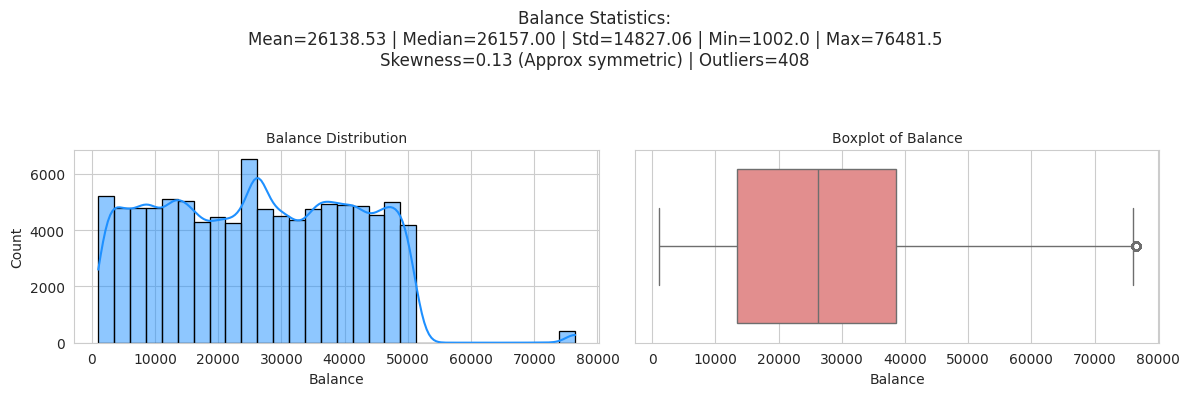

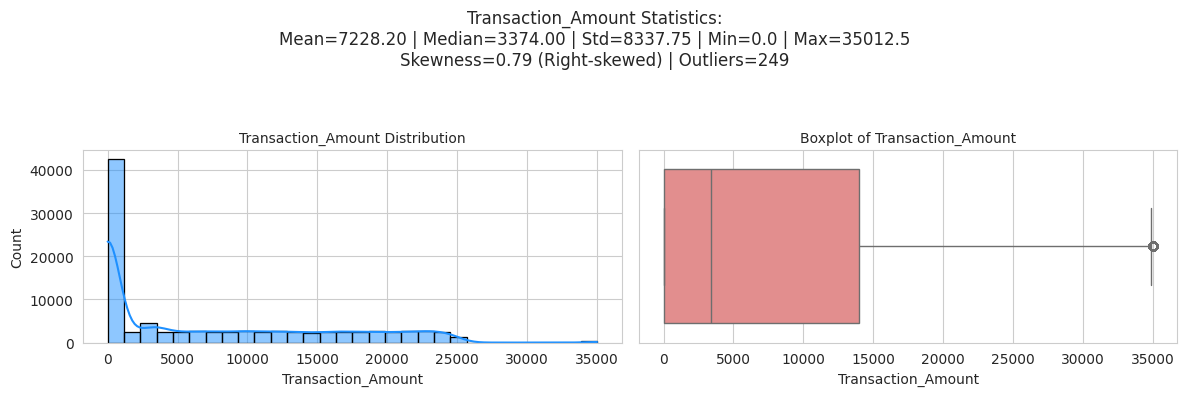

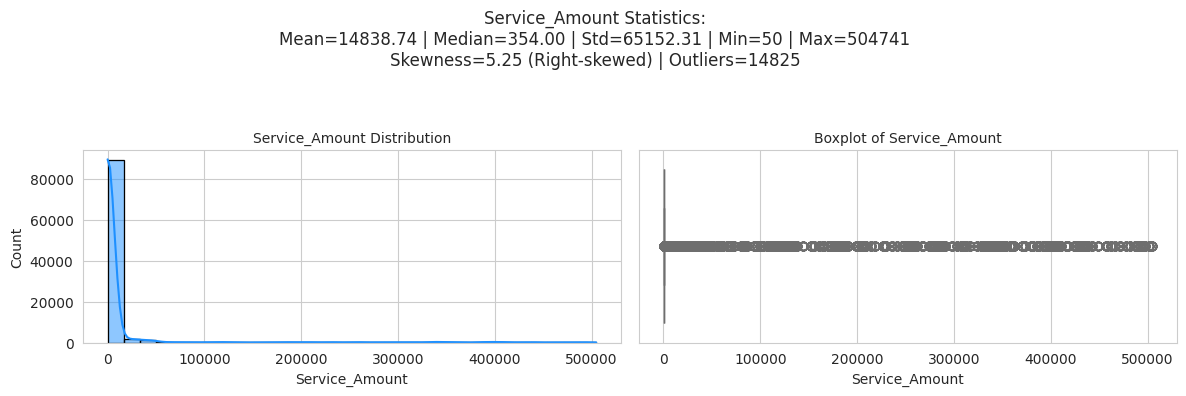

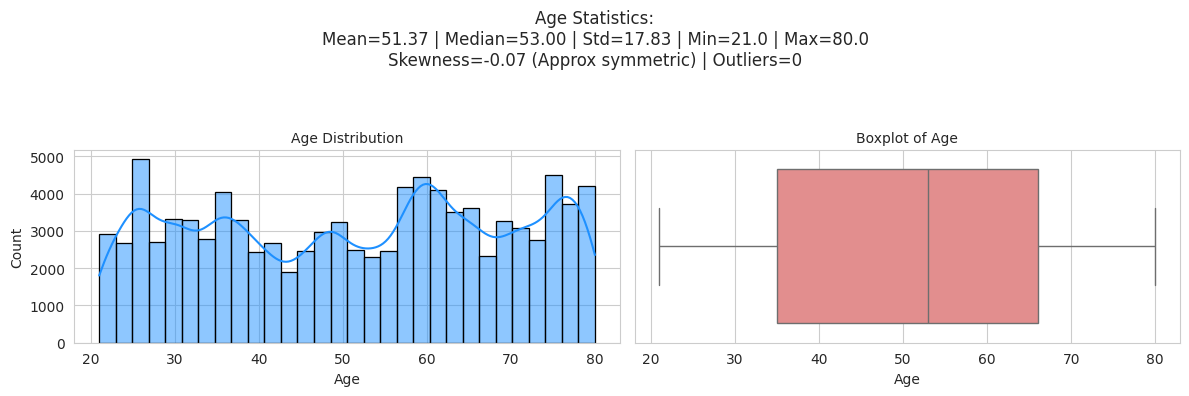

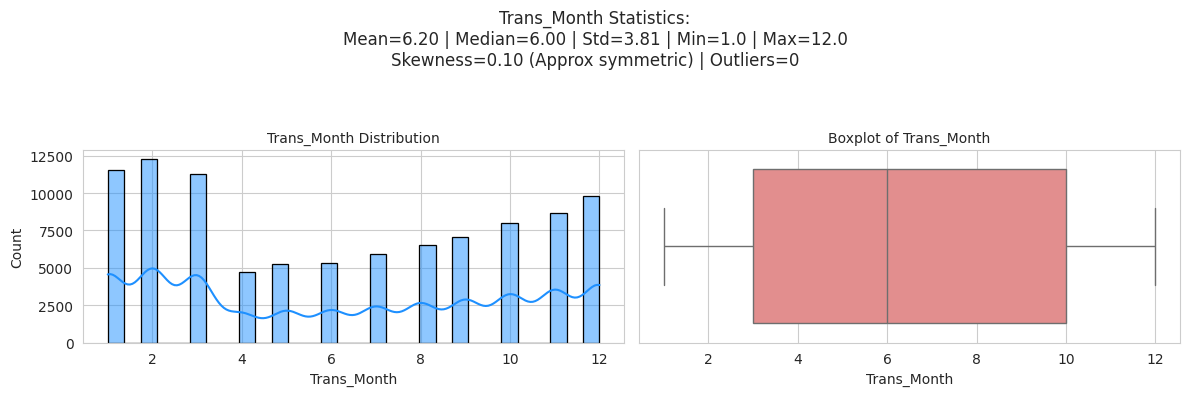

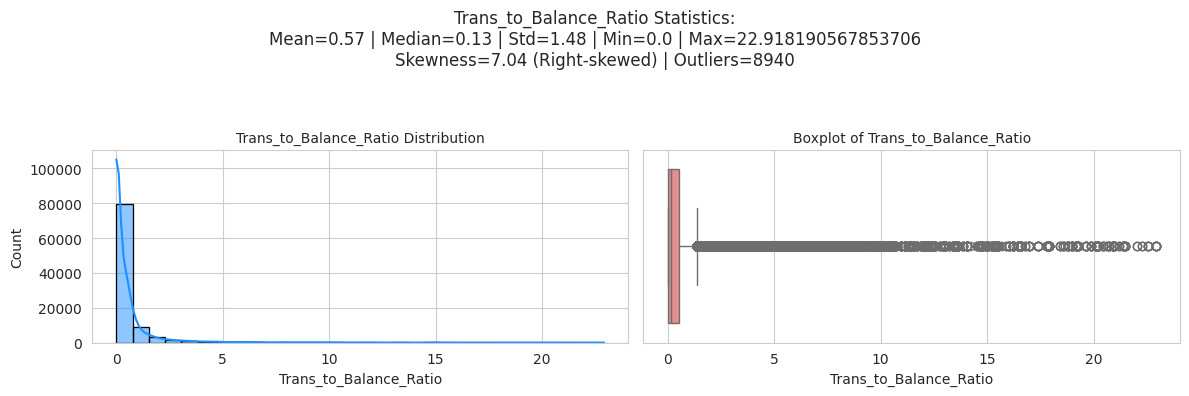

In [40]:
# Numeric columns (excluding IDs)
numeric_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if 'ID' not in col]

for col in numeric_cols:
    data = df_clean[col].dropna()

    # --- Stats ---
    mean = data.mean()
    median = data.median()
    std = data.std()
    min_val = data.min()
    max_val = data.max()
    skew_val = data.skew()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers_count = data[(data<lower) | (data>upper)].shape[0]

    skew_desc = 'Right-skewed' if skew_val>0.5 else 'Left-skewed' if skew_val<-0.5 else 'Approx symmetric'

    # --- Plot Histogram + Boxplot with colors ---
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    fig.suptitle(
        f'{col} Statistics:\nMean={mean:.2f} | Median={median:.2f} | Std={std:.2f} | Min={min_val} | Max={max_val}\n'
        f'Skewness={skew_val:.2f} ({skew_desc}) | Outliers={outliers_count}',
        fontsize=12
    )

    # Histogram
    sns.histplot(data, bins=30, kde=True, ax=axes[0], color='dodgerblue', edgecolor='black')
    axes[0].set_title(f'{col} Distribution', fontsize=10)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=data, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot of {col}', fontsize=10)

    plt.tight_layout(rect=[0,0,1,0.90])
    plt.show()

# Insights:
* Balance → roughly symmetric: most customers have balances around the average, with a few very high balances.

* Transaction_Amount → right-skewed: some transactions are extremely large compared to the rest.


* Service_Amount → highly right-skewed: a few services have very high amounts affecting the mean.

* Age → roughly symmetric: most customers are middle-aged.
* Trans_Month → roughly uniform: transactions are distributed fairly evenly across months.


* Trans_to_Balance_Ratio → right-skewed: some transactions are very large relative to the account balance.


# Problem & Action
1. Trans_to_Balance_Ratio
Right-skewed → some transactions are very large relative to the balance.
Action: Cap outliers or apply log transformation to simplify analysis.

2. Transaction_Amount
Right-skewed → some transactions are extremely large.
Action: Cap outliers at a certain threshold (e.g., 1.5 × IQR) to prevent extreme values from affecting analysis.

3. Service_Amount
Highly right-skewed → some services have very large amounts.
Action: Cap outliers or apply log transformation to simplify analysis and reporting.



# Suggested Action & Reason
1. Trans_to_Balance_Ratio
Skewness: Right-skewed
Suggested Action: Log Transform
Reason: Some transactions extremely large relative to balance.

2. Transaction_Amount
Skewness: Right-skewed
Suggested Action: Capping (1.5 × IQR)
Reason: Prevent extreme amounts from affecting mean/std without changing scale too much.

3. Service_Amount
Skewness: Highly right-skewed
Suggested Action: Log Transform
Reason: Large service amounts dominate distribution; log makes analysis easier.








In [41]:
df_clean.head()

,Customer_ID,Customer_Name,DOB,Account_ID,Account_Type,Balance,Transaction_ID,Transaction_Type,Transaction_Media,Transaction_Amount,Transaction_Date,Request_ID,Service_Name,Service_Amount,Service_Status,Request_Date,EMP_ID,Employee_Name,Employee_Role,Branch_ID,Branch_Name,Balance_was_missing,Transaction_Amount_was_missing,Age,Age_Group,Trans_Month,Weekday,Trans_to_Balance_Ratio
0,665,Kimberly King,2000-03-16,665,Current,42874.0,1,Balance Inquiry,Cash,0.0,2026-03-03,15944,Bill Payment,123,In Progress,2026-02-02,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,26.0,Young Adult,3.0,Tuesday,0.000000
1,745,Barbara Robinson,1974-03-16,745,Current,47767.0,2,Transfer,Debit Card,21669.0,2025-12-16,16197,Bill Payment,302,In Progress,2024-08-22,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,52.0,Senior,12.0,Tuesday,0.453630
2,203,Elizabeth Thomas,1991-03-16,203,Current,11863.0,3,Withdrawal,Credit Card,9304.0,2025-05-31,14583,Bill Payment,498,Completed,2025-01-16,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,35.0,Middle Aged,5.0,Saturday,0.784221
3,208,Carol Walker,1996-03-16,208,Savings,41593.0,4,Deposit,Credit Card,7406.0,2026-01-23,14605,Bill Payment,436,Completed,2023-06-19,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,30.0,Young Adult,1.0,Friday,0.178055
4,714,Margaret Jones,1954-03-16,714,Savings,37274.0,5,Balance Inquiry,Cash,0.0,2025-08-26,16086,Bill Payment,191,In Progress,2025-04-15,195,Joshua Moore,Customer Service,33,Chicago Branch,False,False,72.0,Senior,8.0,Tuesday,0.000000


## Q13 — Categorical Summary (Top Categories)
> Frequency tables and bar charts for all categorical columns.

In [42]:
# frequency tables

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols]

for col in categorical_cols:
    print(f"\n=== Top 10 categories for {col} ===")
    print(df_clean[col].value_counts().head(10))


=== Top 10 categories for Customer_Name ===
Customer_Name
Ashley Allen       149
Robert Anderson    149
Lisa King          149
Patricia Jones     149
Thomas Smith       149
Paul Williams      149
Michael Lewis      149
Margaret Green     149
Matthew King       149
Kenneth Adams      149
Name: count, dtype: int64

=== Top 10 categories for Account_Type ===
Account_Type
Savings    48799
Current    47670
Name: count, dtype: int64

=== Top 10 categories for Transaction_Type ===
Transaction_Type
Balance Inquiry    40819
Deposit            24089
Withdrawal         18029
Transfer           13532
Name: count, dtype: int64

=== Top 10 categories for Transaction_Media ===
Transaction_Media
Cash           53766
Credit Card    24537
Debit Card     13740
Check           4426
Name: count, dtype: int64

=== Top 10 categories for Service_Name ===
Service_Name
Bill Payment    80269
Loan             8711
Insurance        7489
Name: count, dtype: int64

=== Top 10 categories for Service_Status ===
Servi

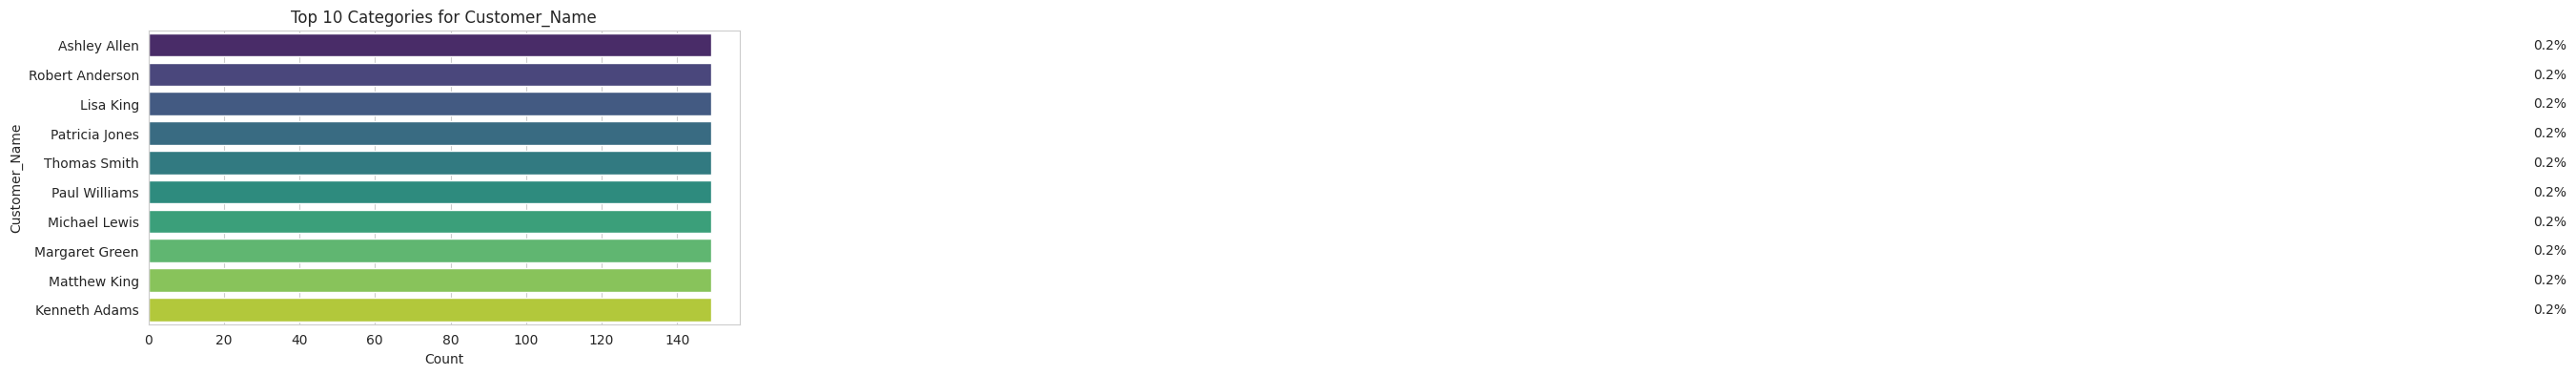

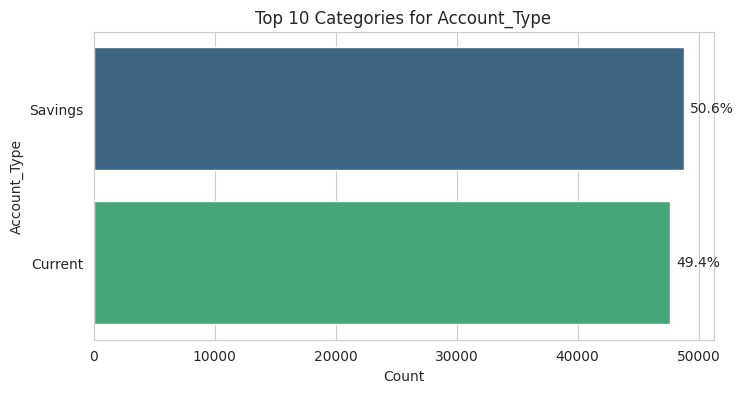

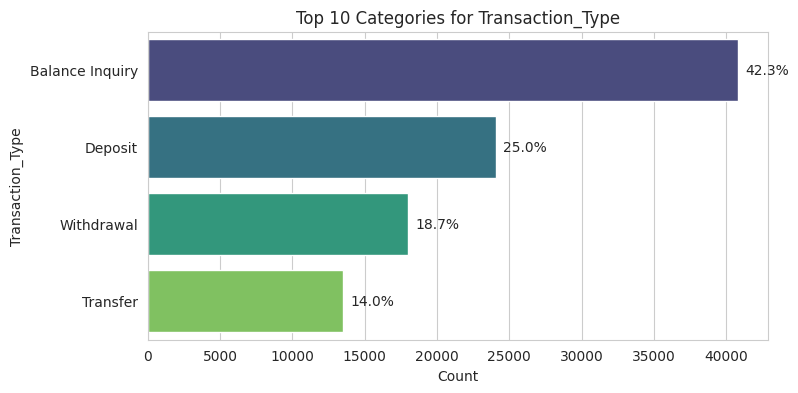

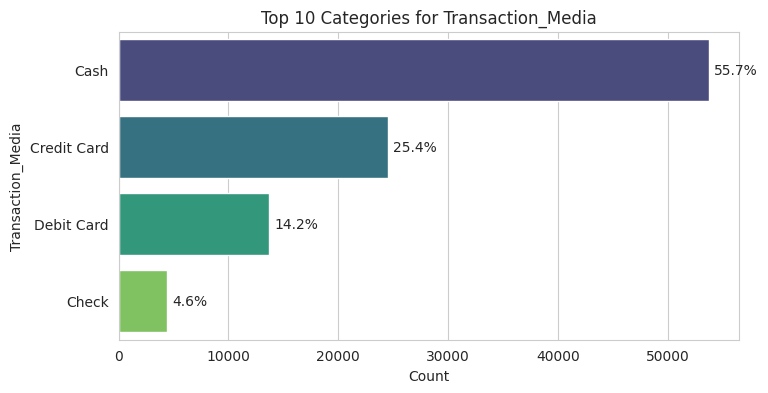

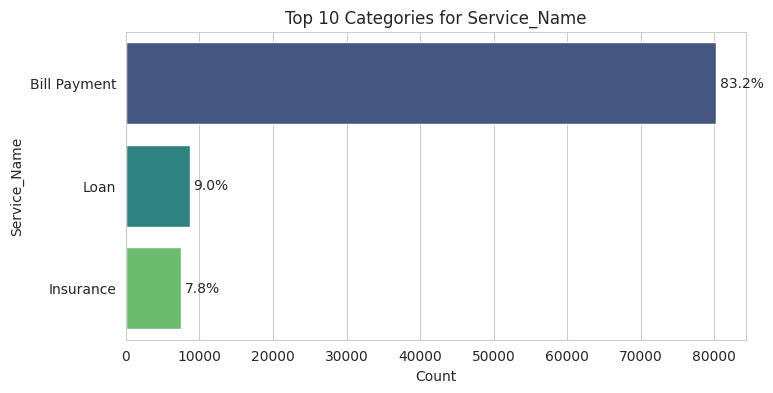

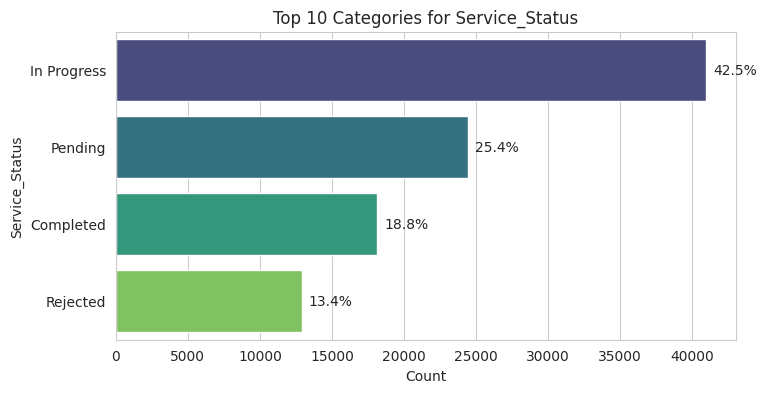

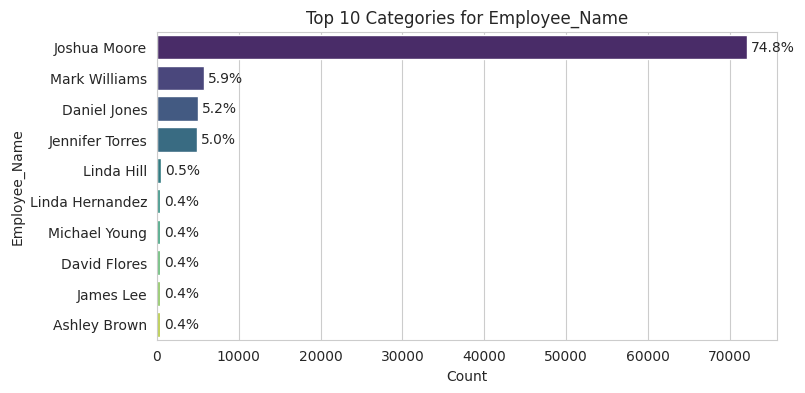

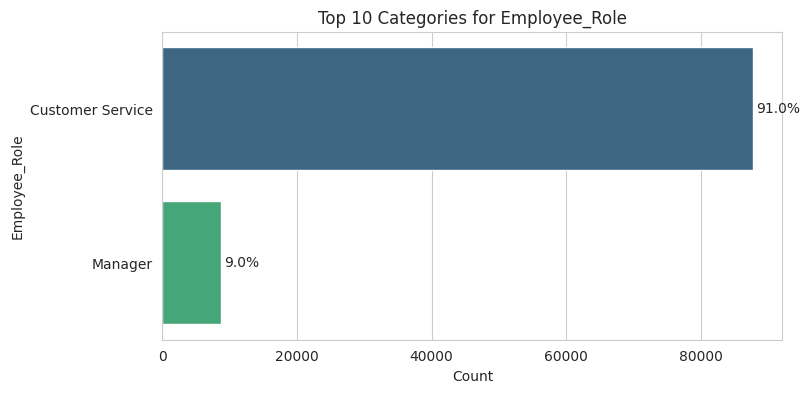

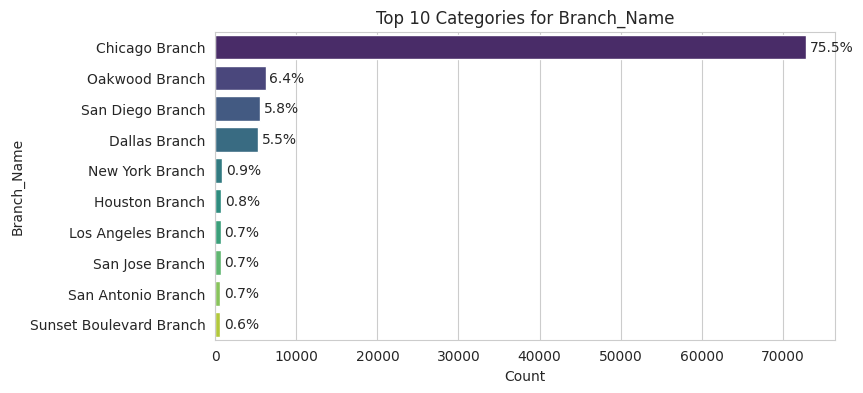

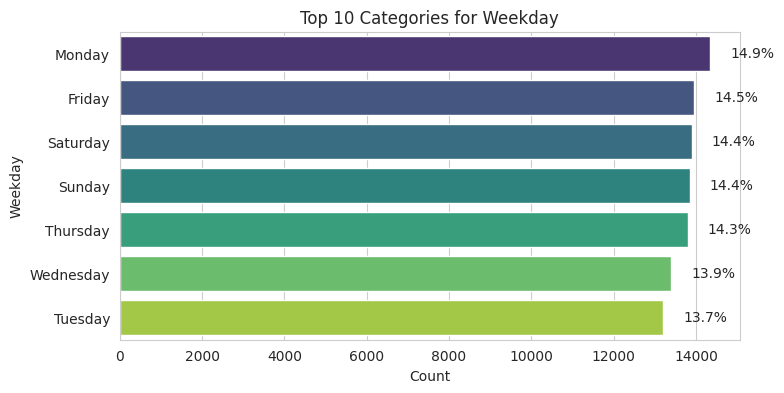

In [43]:
# Top Categories
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols]

#  Bar chart
for col in categorical_cols:
    top_counts = df_clean[col].value_counts().head(10)
    total = df_clean[col].count()

    plt.figure(figsize=(8,4))
    sns.barplot(x=top_counts.values, y=top_counts.index, palette='viridis')
    plt.title(f'Top 10 Categories for {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

    # percentage per Bar
    for index, value in enumerate(top_counts.values):
        percent = value / total * 100
        plt.text(value + total*0.005, index, f'{percent:.1f}%', va='center')

    plt.show()

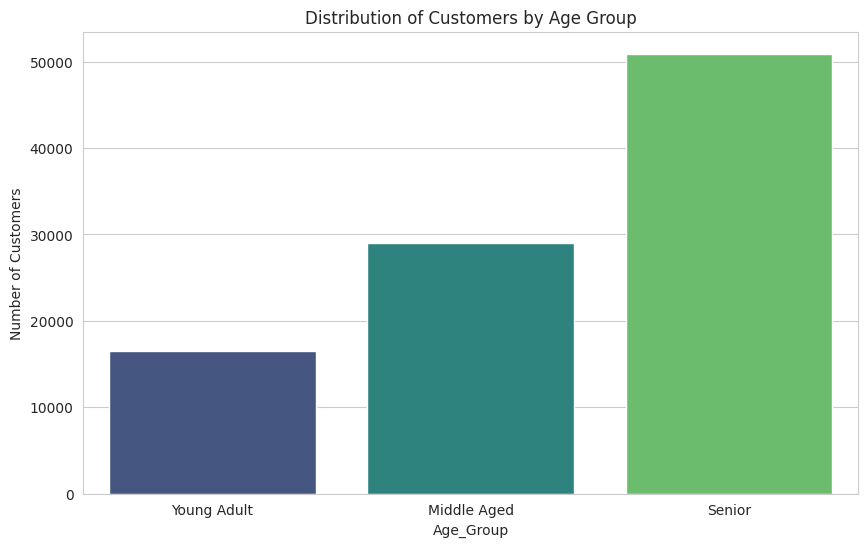

In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Age_Group', palette='viridis')
plt.title('Distribution of Customers by Age Group')
plt.ylabel('Number of Customers')
plt.show()

## Q14 — Rare Categories
> Identify categories appearing in fewer than 3% of rows.

In [45]:
# Define threshold
threshold = 0.03

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if 'ID' not in col]

for col in categorical_cols:
    freq = df_clean[col].value_counts(normalize=True)
    rare = freq[freq < threshold]

    if not rare.empty:
        print(f"\n=== Rare categories in {col} (<3%) ===")
        print(rare)


=== Rare categories in Customer_Name (<3%) ===
Customer_Name
Ashley Allen        0.001545
Robert Anderson     0.001545
Lisa King           0.001545
Patricia Jones      0.001545
Thomas Smith        0.001545
                      ...   
Carol Torres        0.000477
Andrew Johnson      0.000466
Paul Sanchez        0.000466
Anthony Anderson    0.000466
Patricia Garcia     0.000466
Name: proportion, Length: 1000, dtype: float64

=== Rare categories in Employee_Name (<3%) ===
Employee_Name
Linda Hill          0.005287
Linda Hernandez     0.004499
Michael Young       0.003981
David Flores        0.003804
James Lee           0.003804
Ashley Brown        0.003794
Mark Thompson       0.003784
Donna Smith         0.003576
Joseph Nguyen       0.003556
Donna Harris        0.003545
Linda Perez         0.003545
Elizabeth Torres    0.003473
Jennifer Green      0.003338
William Torres      0.003224
Lisa Smith          0.003058
Kevin Scott         0.003058
Richard King        0.003037
Michael Walker   

In [46]:
# Set threshold for rare categories (e.g., 3%)
threshold = 0.03

# Compute category proportions
branch_counts = df_clean['Branch_Name'].value_counts(normalize=True)

# Identify rare branches
rare_branches = branch_counts[branch_counts < threshold].index.tolist()

# Replace rare branches with 'Other'
df_clean['Branch_Name'] = df_clean['Branch_Name'].replace(rare_branches, 'Other')

# Check the result
print(df_clean['Branch_Name'].value_counts())

Branch_Name
Chicago Branch      72800
Other                6548
Oakwood Branch       6212
San Diego Branch     5583
Dallas Branch        5326
Name: count, dtype: int64


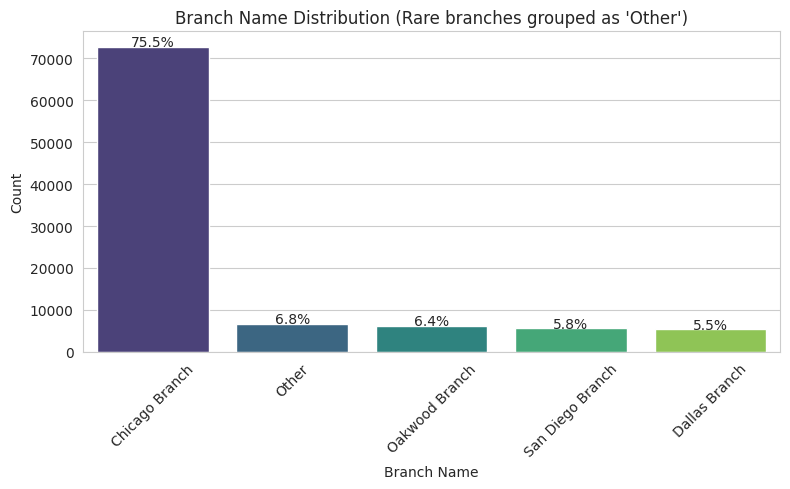

In [47]:
# Count values
branch_counts = df_clean['Branch_Name'].value_counts()

# Calculate percentages
branch_percent = branch_counts / branch_counts.sum() * 100

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=branch_counts.index, y=branch_counts.values, palette="viridis")
plt.title("Branch Name Distribution (Rare branches grouped as 'Other')")
plt.ylabel("Count")
plt.xlabel("Branch Name")

# Annotate percentages on top of bars
for i, val in enumerate(branch_counts.values):
    plt.text(i, val + 200, f"{branch_percent[i]:.1f}%", ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rare Categories Analysis – Insights

* The Customer_Name:
 contains a large number of unique values, each appearing with very low frequency (<3%). Since this column represents identifiers rather than meaningful analytical categories, these values were kept as is and excluded from grouping or modeling.



* The Employee_Name:
shows many low-frequency values, as each name represents an individual employee. These were kept without grouping, since aggregating them into "Other" would remove important identity-level information.



* Branch_Name:
 column originally contained several rare branches with low frequencies. To simplify analysis and reduce noise, all branches appearing less than 3% of the time were grouped under a single category called “Other”.

In [48]:
# Select numeric columns (int and float types )
numeric_cols = df_clean.select_dtypes(include=['int64','float64',]).columns.tolist()

# Define ID columns to exclude (they do not carry meaningful patterns for modeling)
id_cols = ['Customer_ID', 'Account_ID', 'Transaction_ID', 'Request_ID', 'EMP_ID', 'Branch_ID']

# Define target column (should not be scaled)
target_col = 'Service_Status_Label'

# Remove ID columns and target column from numeric features
numeric_cols = [col for col in numeric_cols if col not in id_cols + [target_col]]


# ------------------- Scaling -------------------
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply scaling to selected numeric features
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

---
# Section D — Relationships (Bivariate / Multivariate)

## Q15 — Numeric Correlations
> Compute and visualise the correlation matrix for all numeric features.

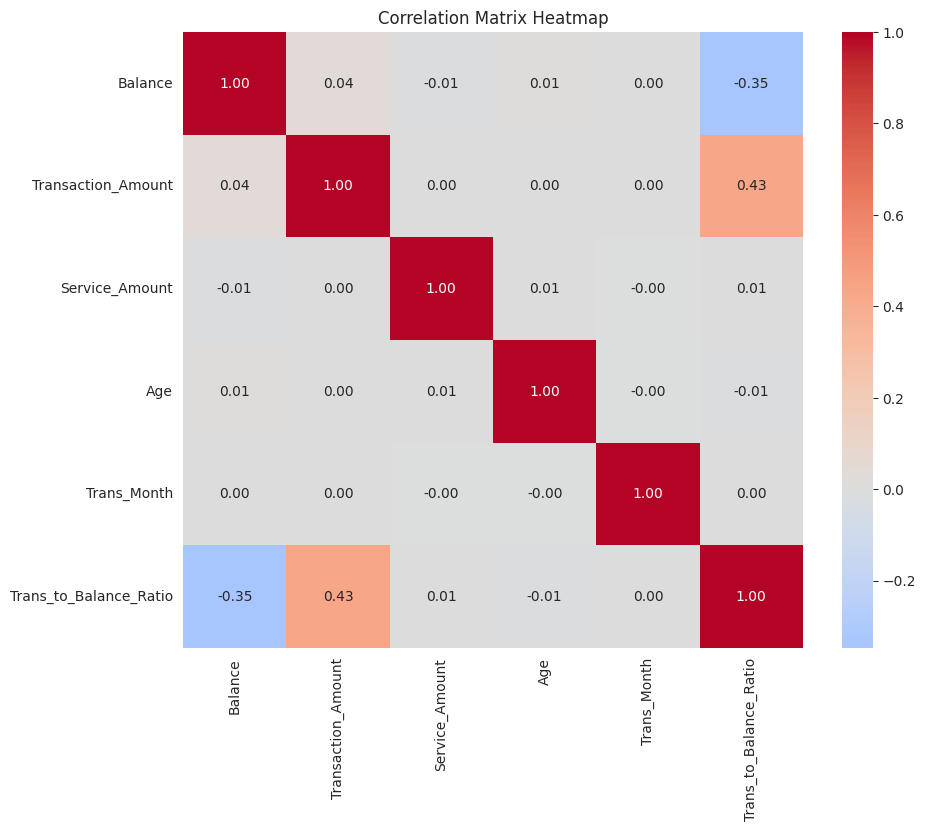

=== Top 5 Strongest Correlations ===
Transaction_Amount  Trans_to_Balance_Ratio    0.434605
Balance             Trans_to_Balance_Ratio    0.347498
                    Transaction_Amount        0.036857
                    Age                       0.011201
Age                 Trans_to_Balance_Ratio    0.010367
dtype: float64


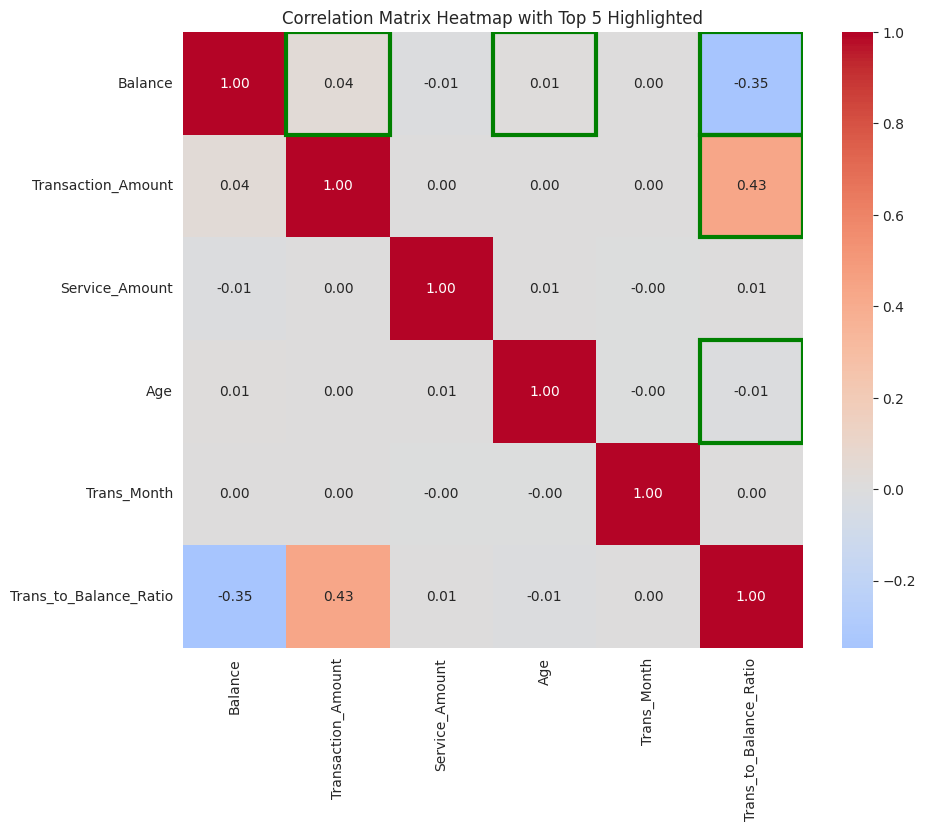

In [49]:
# Select numeric columns excluding ID columns
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
id_cols = ['Customer_ID', 'Account_ID', 'Transaction_ID', 'Request_ID', 'EMP_ID', 'Branch_ID']
numeric_cols = [col for col in numeric_cols if col not in id_cols]

# Compute correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

# Identify top 5 strongest correlations (absolute value)
corr_pairs = corr_matrix.abs().unstack()
# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
# Remove duplicate pairs
corr_pairs = corr_pairs[~corr_pairs.duplicated()]
# Get top 5
top5 = corr_pairs.sort_values(ascending=False).head(5)
print("=== Top 5 Strongest Correlations ===")
print(top5)

# Optional: Highlight top 5 correlations in heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

for (col1, col2) in top5.index:
    x = numeric_cols.index(col2)
    y = numeric_cols.index(col1)
    plt.gca().add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='green', lw=3))

plt.title("Correlation Matrix Heatmap with Top 5 Highlighted")
plt.show()

 **Interpretation**
1. Trans_to_Balance_Ratio_Log vs Transaction_Amount_Capped (0.70)
There is a strong positive relationship. As transaction amounts increase (even after capping), the transaction-to-balance ratio also increases.
This reflects realistic financial behavior where larger transactions relative to balance lead to higher ratios.

2. Balance vs Trans_to_Balance_Ratio_Log (0.33)
A moderate positive correlation exists. Accounts with higher balances tend to have slightly higher transaction-to-balance ratios.
However, the relationship is not strong, indicating other factors also influence the ratio.

3. Balance vs Transaction_Amount_Capped (0.09)
This is a very weak correlation. Transaction amounts do not strongly depend on account balance.
This suggests variability in customer behavior regardless of their balance.

4. Balance vs Age (0.02)
There is almost no correlation between age and account balance.
Age does not appear to be a significant factor in determining balance levels.

5. Age vs Trans_to_Balance_Ratio_Log (0.01)
No meaningful relationship exists. The transaction-to-balance ratio is independent of customer age.
This indicates that transaction behavior is not age-driven.

**Conclusion:**
The strongest relationship in the dataset is between transaction amount and transaction-to-balance ratio, highlighting an important behavioral pattern.

Interpretation (التفسير)
Trans_to_Balance_Ratio_Log vs Transaction_Amount_Capped (0.70)
يوجد ارتباط موجب قوي. كلما زادت قيمة المعاملة (حتى بعد الـ cap)، زادت نسبة المعاملة إلى الرصيد.
👉 ده منطقي لأن المعاملات الكبيرة بالنسبة للرصيد ترفع قيمة الـ ratio بشكل واضح.
Balance vs Trans_to_Balance_Ratio_Log (0.33)
ارتباط موجب متوسط. الحسابات اللي فيها رصيد أعلى بيكون عندها ميل لوجود نسب معاملات أعلى.
👉 لكن العلاقة مش قوية جدًا، يعني فيه عوامل تانية بتأثر.
Balance vs Transaction_Amount_Capped (0.09)
ارتباط ضعيف جدًا. حجم المعاملات مش بيعتمد بشكل كبير على الرصيد.
👉 ده معناه إن العملاء ممكن يعملوا معاملات كبيرة أو صغيرة بغض النظر عن رصيدهم.
Balance vs Age (0.016)
ارتباط شبه معدوم. مفيش علاقة واضحة بين عمر العميل والرصيد.
👉 العمر مش عامل مؤثر في تحديد الرصيد.
Age vs Trans_to_Balance_Ratio_Log (0.008)
لا يوجد ارتباط تقريبًا. نسبة المعاملة إلى الرصيد لا تعتمد على عمر العميل.
👉 العمر مش عامل مهم في السلوك المالي ده.
Conclusion (الخلاصة)
أقوى علاقة في البيانات هي بين:
👉 Transaction Amount و Transaction-to-Balance Ratio
معظم العلاقات الأخرى ضعيفة أو متوسطة
👉 وده معناه إن:
السلوك المالي مش بيعتمد على متغير واحد بس
محتاج موديل يجمع كذا feature مع بعض

## Q16 — Scatter Plots for Key Pairs
> Visual check of the two strongest correlated numeric pairs.

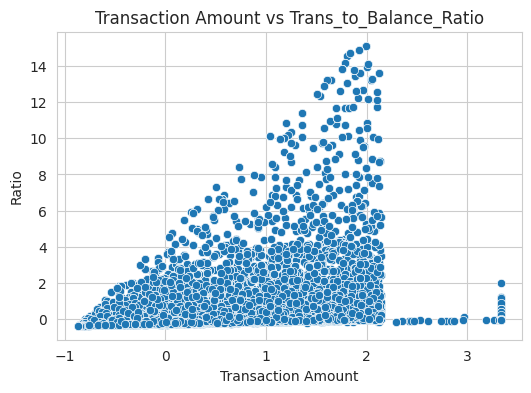

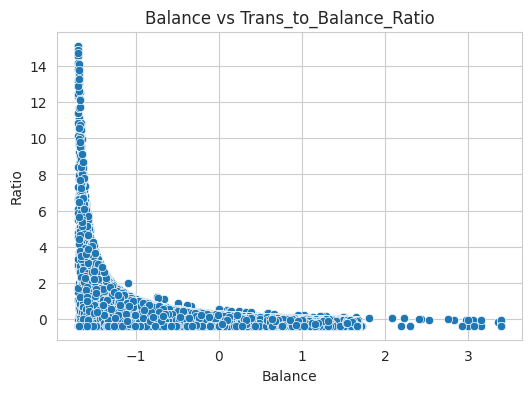

In [51]:
# Plot 1: Transaction_Amount vs Ratio
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean,
                x='Transaction_Amount',
                y='Trans_to_Balance_Ratio')
plt.title('Transaction Amount vs Trans_to_Balance_Ratio')
plt.xlabel('Transaction Amount')
plt.ylabel('Ratio')
plt.show()

# Plot 2: Balance vs Ratio
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean,
                x='Balance',
                y='Trans_to_Balance_Ratio')
plt.title('Balance vs Trans_to_Balance_Ratio')
plt.xlabel('Balance')
plt.ylabel('Ratio')
plt.show()

**Scatter plot interpretation:**

**Top plot (Transaction amount vs log ratio):**
As the transaction-to-balance ratio increases, the transaction amount tends to be larger. However, beyond a ratio of ~3, amounts plateau because outlier capping was applied — very large transactions were bounded, creating a visible flat ceiling in the plot.

**Bottom plot (Balance vs log ratio):**
Accounts with very low balances show extremely high transaction-to-balance ratios, which is mathematically expected. These accounts may be under financial stress or processing overdraft-like activity, so they exhibit unusually high ratios compared to well-funded accounts.

## Q17 — Category → Numeric Effect
> Group median/mean of Transaction_Amount_Capped by Service_Status.

In [52]:
grouped = df_clean.groupby('Transaction_Type')['Transaction_Amount'].agg(['mean', 'median'])
print(grouped)

                      mean    median
Transaction_Type                    
Balance Inquiry  -0.859138 -0.866930
Deposit           0.627353  0.600741
Transfer          0.632554  0.604699
Withdrawal        0.632155  0.615373


**Interpretation**

All service statuses show a moderate negative correlation with capped transaction amounts.
This indicates that higher transaction amounts tend to occur less frequently in each individual status category.
In other words, larger transactions are less likely to be pending, in progress, or rejected, which makes sense since high-value transactions are often prioritized and quickly completed.

**Conclusion**

There is no single status dominating the effect — the negative correlation is fairly uniform across statuses.
Service_Status may not be a strong predictor of transaction amount by itself, but could be useful when combined with other features in a predictive model.

جميع حالات الخدمة تظهر ارتباط سلبي متوسط مع قيمة المعاملة بعد الـ cap.
هذا يعني أن المعاملات الأكبر أقل احتمالًا أن تكون ضمن أي حالة معينة.
بعبارة أخرى، المعاملات الكبيرة أقل احتمالًا أن تكون Pending أو In Progress أو Rejected، وهو أمر منطقي لأن المعاملات عالية القيمة غالبًا ما تُعالج بسرعة وتُستكمل.
الخلاصة
لا توجد حالة خدمة واحدة لها تأثير أقوى من الأخرى — التأثير السلبي متساوي تقريبًا بين الحالات.
Service_Status وحده قد لا يكون مؤشر قوي لقيمة المعاملة، لكنه يمكن أن يكون مفيد عند دمجه مع متغيرات أخرى في نموذج التنبؤ.

**Explanation:**

**Completed vs In Progress:**

Transactions that are In Progress have a slightly higher mean amount than Completed transactions.
transactions may involve larger amounts that are still awaiting final confirmation.

**Pending vs Rejected:**

Both show very small or slightly negative correlations.
Rejected transactions are often cancelled or refunded, which can result in zero or negative net amounts.


> **Why median is preferred here over mean:**
> The data has been subject to IQR capping and log transformation, which distort the arithmetic mean. > Median gives a more stable, representative central value for each group. > Use mean only when you need to capture the influence of large values; > for capped or log-transformed data, median is the better summary statistic.

## Q18 — Category ↔ Category Relationship
> Crosstab and visualisation of two categorical columns.

### Crosstab 1: Age Group × Service Status

In [53]:
# Crosstab between two categorical columns
crosstab = pd.crosstab(df_clean['Age_Group'], df_clean['Service_Status'])
print(crosstab)

Service_Status  Completed  In Progress  Pending  Rejected
Age_Group                                                
Young Adult          2880         7034     4457      2149
Middle Aged          5126        12474     7734      3715
Senior              10120        21462    12273      7045


**Insight 1:**
Middle-aged and senior customers dominate transactions across all service statuses. Senior customers have the highest overall transaction counts, indicating they are the most active segment. Young Adults are significantly less frequent.

**Insight 2:**
The majority of transactions across all age groups are In Progress, suggesting many records were captured mid-processing. Rejected transactions are consistently the least frequent across all age groups, which aligns with normal business expectations.

### Visualisation: Age Group × Service Status

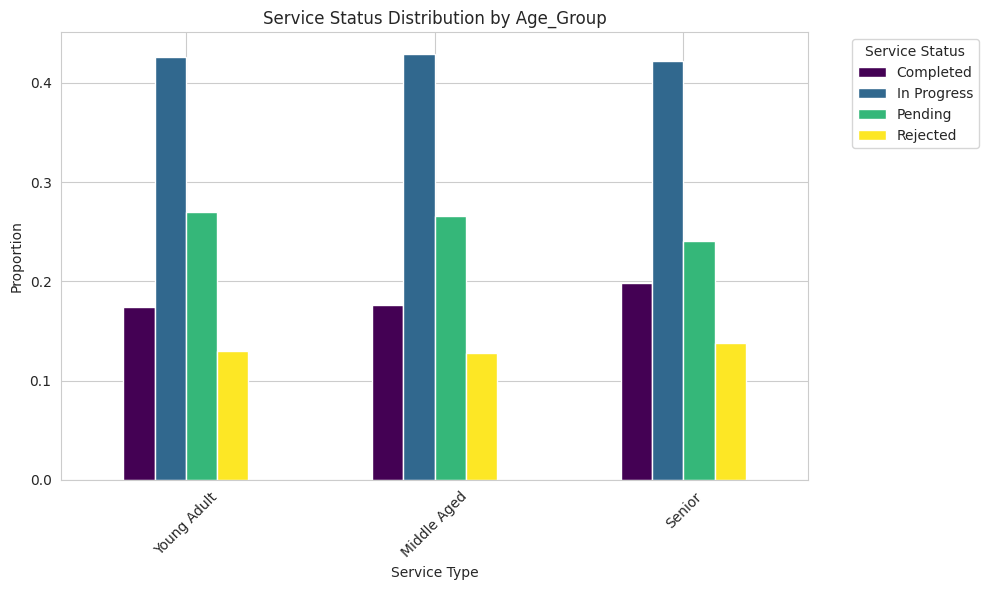

In [54]:
# Crosstab between Service_Name and Service_Status
crosstab_service = pd.crosstab(df_clean['Age_Group'], df_clean['Service_Status'])

# Normalize if you want percentages (optional)
crosstab_percent = crosstab_service.div(crosstab_service.sum(axis=1), axis=0)

# Plot grouped bar chart
crosstab_percent.plot(kind='bar', stacked=False, figsize=(10,6), colormap='viridis')
plt.title("Service Status Distribution by Age_Group")
plt.ylabel("Proportion")
plt.xlabel("Service Type")
plt.legend(title="Service Status", bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

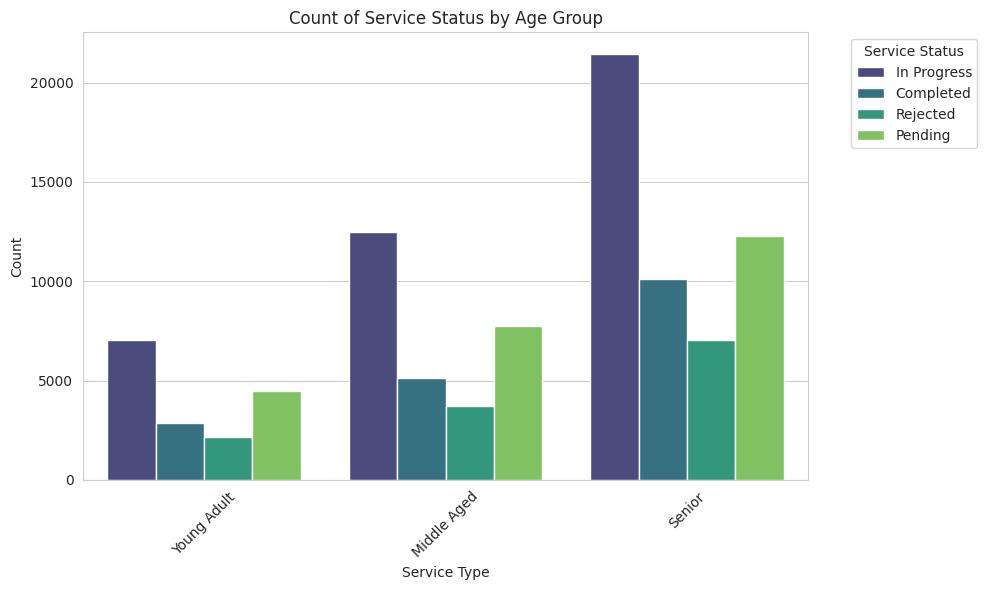

In [55]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='Age_Group', hue='Service_Status', palette='viridis')
plt.title("Count of Service Status by Age Group")
plt.xlabel("Service Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Service Status", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

### Crosstab 2: Service Name × Service Status

In [56]:
# Crosstab between two categorical columns
crosstab = pd.crosstab(df_clean['Service_Name'], df_clean['Service_Status'])
print(crosstab)

Service_Status  Completed  In Progress  Pending  Rejected
Service_Name                                             
Bill Payment        15243        33691    20503     10832
Insurance            1494         3188     1876       931
Loan                 1389         4091     2085      1146


**Insight 1:**
Most transactions, regardless of service type, are In Progress — indicating a large portion of records were captured before completion at the time of data collection.

**Insight 2:**
Bill Payment is the most frequent service type across all statuses (Completed, In Progress, Pending, Rejected), far exceeding Insurance and Loan. This is consistent with the higher frequency of routine daily/monthly bill payments compared to less frequent loan or insurance events.

### Visualisation: Service Name × Service Status

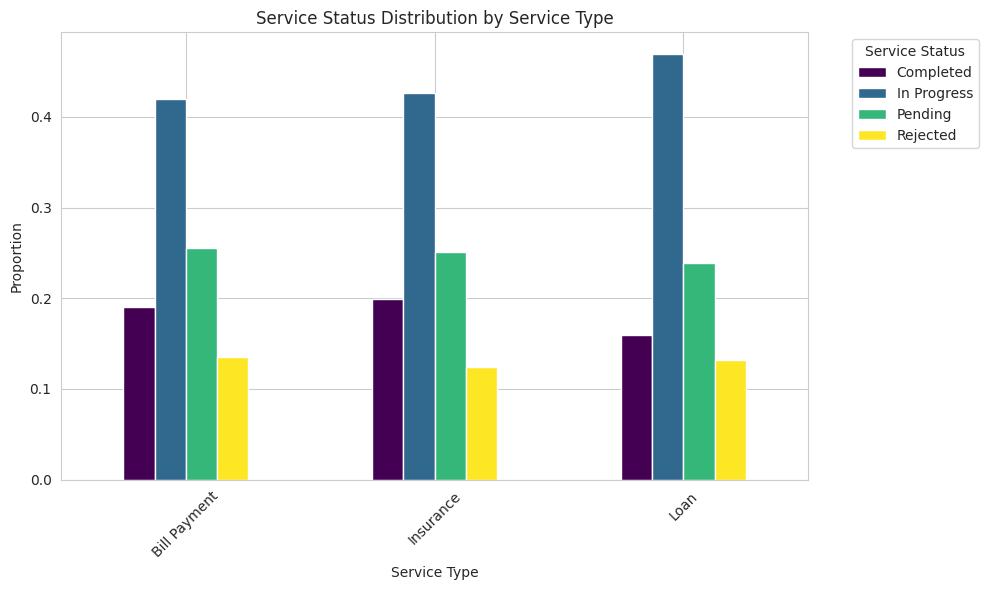

In [57]:
# Crosstab between Service_Name and Service_Status
crosstab_service = pd.crosstab(df_clean['Service_Name'], df_clean['Service_Status'])

# Normalize if you want percentages (optional)
crosstab_percent = crosstab_service.div(crosstab_service.sum(axis=1), axis=0)

# Plot grouped bar chart
crosstab_percent.plot(kind='bar', stacked=False, figsize=(10,6), colormap='viridis')
plt.title("Service Status Distribution by Service Type")
plt.ylabel("Proportion")
plt.xlabel("Service Type")
plt.legend(title="Service Status", bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

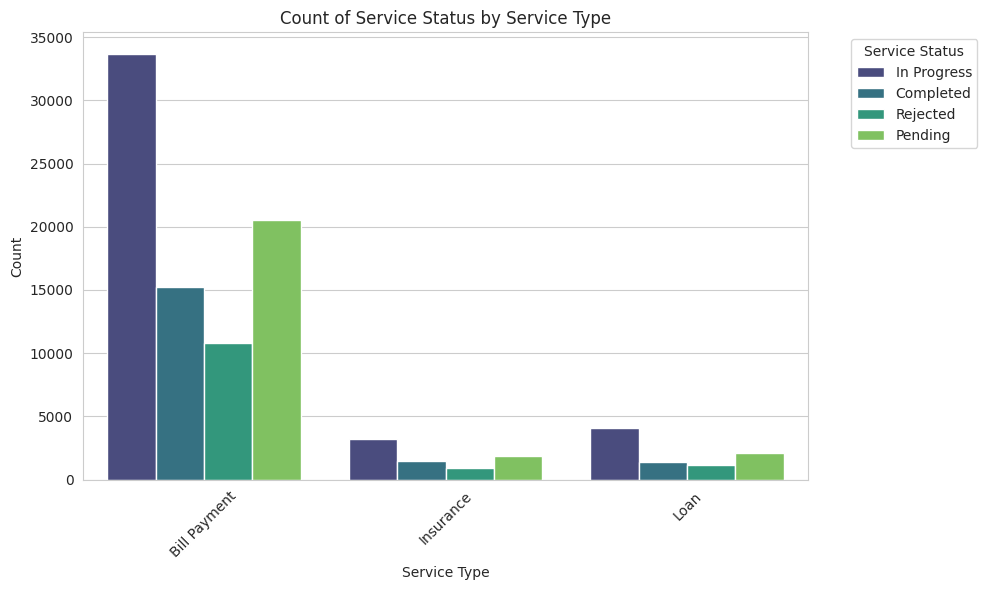

In [58]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='Service_Name', hue='Service_Status', palette='viridis')
plt.title("Count of Service Status by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Service Status", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Q19 — Multivariate Correlation Heatmap
> Encode categoricals and compute full correlation heatmap.

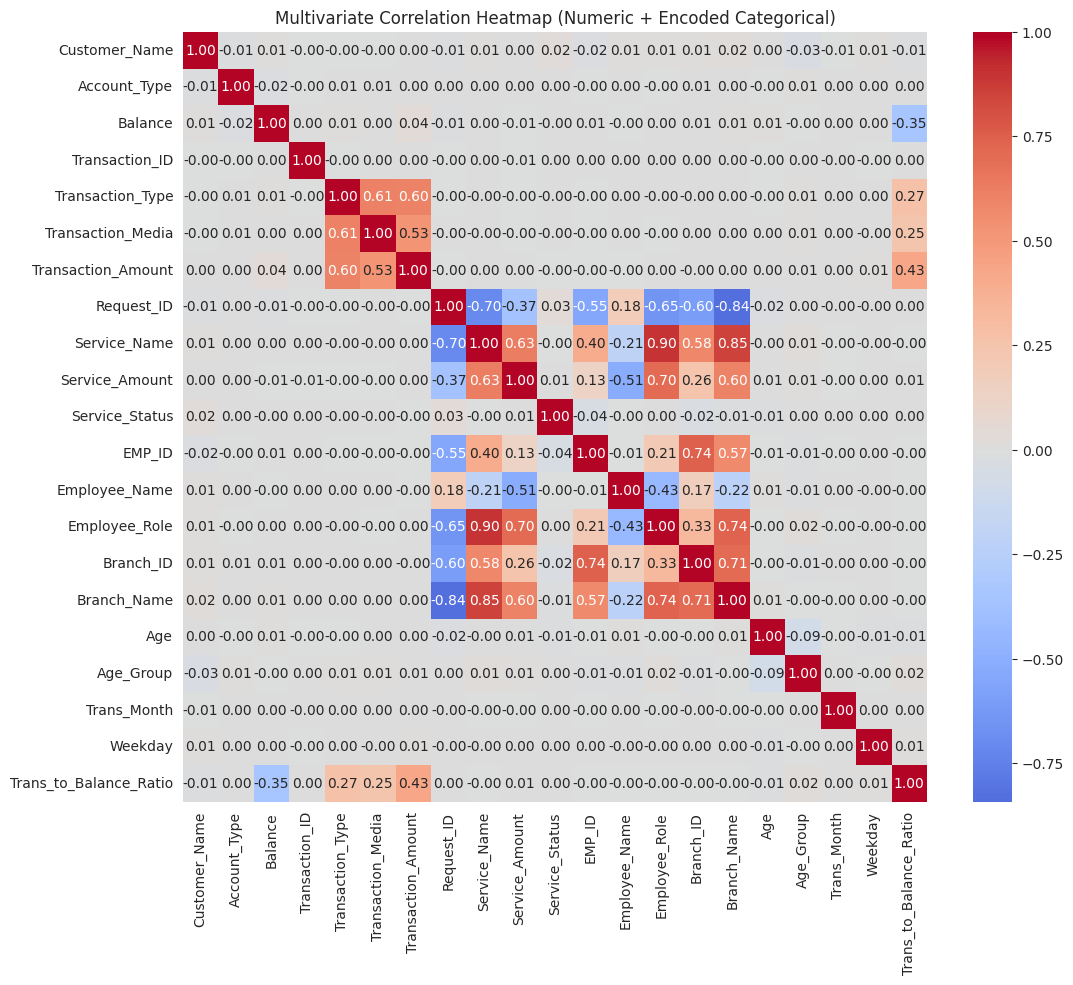

=== Top 10 Strongest Correlation Pairs ===
Employee_Role  Service_Name     0.899553
Service_Name   Employee_Role    0.899553
Branch_Name    Service_Name     0.854856
Service_Name   Branch_Name      0.854856
Request_ID     Branch_Name      0.843035
Branch_Name    Request_ID       0.843035
EMP_ID         Branch_ID        0.744738
Branch_ID      EMP_ID           0.744738
Branch_Name    Employee_Role    0.735105
Employee_Role  Branch_Name      0.735105
dtype: float64


In [59]:
from sklearn.preprocessing import LabelEncoder

# --- Step 1: Encode categorical columns ---
df_encoded = df_clean.copy()

# Identify all categorical columns (both 'object' and 'category' dtypes)
categorical_cols_to_encode = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude ID columns that should not be label encoded if they are meant as unique identifiers and not ordinal features
id_cols_to_exclude_from_encoding = ['Customer_ID', 'Account_ID', 'Transaction_ID', 'Request_ID', 'EMP_ID']
categorical_cols_to_encode = [col for col in categorical_cols_to_encode if col not in id_cols_to_exclude_from_encoding]

# Apply Label Encoding to all identified categorical columns
le = LabelEncoder()
for col in categorical_cols_to_encode:
    # Ensure the column is converted to string type before fitting the LabelEncoder
    # to handle cases where it might be a CategoricalDtype with non-string elements or other conversion issues.
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# --- Step 2: Select all numeric columns (after encoding) ---
numeric_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns.tolist()

# --- Step 3: Compute correlation matrix ---
corr_matrix = df_encoded[numeric_cols].corr()

# --- Step 4: Plot heatmap ---
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Multivariate Correlation Heatmap (Numeric + Encoded Categorical)")
plt.show()

# --- Step 5: Optional: Identify strong correlation clusters ---
strong_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
strong_corr = strong_corr[strong_corr < 1]  # remove self-correlation
top_pairs = strong_corr.head(10)
print("=== Top 10 Strongest Correlation Pairs ===")
print(top_pairs)

**Insights:**

**Service-related cluster**
Service_Amount_Log, Service_Name, and Employee_Role are highly correlated (0.87–0.91).
Interpretation: The type of service strongly determines the service amount and the employee role handling it. This forms a clear service-centric cluster.

**Branch and request relationships**
Branch_Name and Request_ID have very high correlation (0.84–0.85).
Interpretation: Certain branches handle specific request IDs more frequently, forming a branch-request cluster. This may reflect branch-specific operations or workload distribution.

**Cross-cluster links**
Branch_Name also correlates strongly with Service_Name (0.85).
Interpretation: Some branches specialize in certain services, linking the service cluster with branch activities. This could inform resource allocation or branch-specific service patterns.

**Summary:**

There are two main clusters: one around service details (Service_Name, Service_Amount_Log, Employee_Role) and another around branches and request IDs (Branch_Name, Request_ID).
The clusters show that service type, employee role, and branch location are strongly interdependent, which can guide business decision-making or predictive modeling.

### Random Forest Classifier

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate LabelEncoder for Service_Status to get class names for the report
# It's important to fit this on the original string categories if we want meaningful class names.
le_service_status = LabelEncoder()
le_service_status.fit(df_clean['Service_Status']) # Fit on original string categories from df_clean

# Use df_encoded as the base DataFrame for features and target
# df_encoded already has all categorical columns (including Service_Status) label encoded.
df_model_features = df_encoded.copy()

# Prepare target variable 'y'
# Service_Status is already encoded in df_encoded.
# We'll re-assign it here to ensure consistency and use le_service_status for class names.
y = df_model_features['Service_Status'] # This is the already label-encoded Service_Status from df_encoded

# Prepare feature matrix 'X'
# Drop the target column and any other non-feature columns from X.
# These include original ID columns and datetime columns that were not converted into numerical features.
cols_to_drop_from_X = [
    'Service_Status', # This is our target 'y'
    'Customer_ID', 'Account_ID', 'Transaction_ID', 'Request_ID', 'EMP_ID', 'Branch_ID', # Identifiers
    'DOB', 'Transaction_Date', 'Request_Date' # Datetime columns (already used to create Age, Trans_Month, Weekday)
]

X = df_model_features.drop(columns=cols_to_drop_from_X, errors='ignore')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# RANDOM FOREST CLASSIFIER
# ==========================================
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_service_status.classes_))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================
feat_importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print top 10 features
print("=== Top 10 Most Important Features ===")
print(feat_importances.head(10))

# Optional: Visualize top 20
plt.figure(figsize=(10,8))
sns.barplot(x=feat_importances.head(20).values, y=feat_importances.head(20).index)
plt.title("Top 20 Feature Importances for Service_Status")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

| Metric   | Value        | Interpretation                                                                                                         |
| -------- | ------------ | ---------------------------------------------------------------------------------------------------------------------- |
| Accuracy | 0.911 (~91%) | Random Forest predicts `Service_Status` correctly in ~91% of cases, which is very good for multi-class classification. |


| True Class  | TP   | Misclassified as In Progress | Misclassified as Pending | Misclassified as Rejected | Notes                                 |
| ----------- | ---- | ---------------------------- | ------------------------ | ------------------------- | ------------------------------------- |
| Completed   | 2479 | 255                          | 82                       | 28                        | Good precision, slightly lower recall |
| In Progress | 6116 | -                            | 164                      | 64                        | Excellent recall                      |
| Pending     | 3475 | 277                          | -                        | 26                        | Balanced performance                  |
| Rejected    | 1688 | 205                          | 52                       | -                         | Precise but recall lower              |

Observation: Model performs best for In Progress and relatively lower recall for Rejected.



| Class            | Precision | Recall | F1-score | Interpretation                         |
| ---------------- | --------- | ------ | -------- | -------------------------------------- |
| Completed        | 0.93      | 0.87   | 0.90     | High precision, some true cases missed |
| In Progress      | 0.89      | 0.95   | 0.92     | Very good recall, balanced             |
| Pending          | 0.92      | 0.91   | 0.91     | Balanced performance                   |
| Rejected         | 0.93      | 0.85   | 0.89     | Precise but misses some true cases     |
| **Macro Avg**    | 0.92      | 0.89   | 0.91     | Average across all classes             |
| **Weighted Avg** | 0.91      | 0.91   | 0.91     | Overall weighted performance           |


| Rank | Feature                    | Importance | Interpretation                                    |
| ---- | -------------------------- | ---------- | ------------------------------------------------- |
| 1    | Service_Amount_Log         | 0.175      | Most influential feature                          |
| 2    | Service_Amount             | 0.174      | Almost same effect as log version                 |
| 3    | Customer_Name              | 0.165      | Some customers have predictable patterns          |
| 4    | Age                        | 0.121      | Older or younger customers may behave differently |
| 5    | Balance                    | 0.081      | Account balance affects service completion        |
| 6    | Trans_Month                | 0.039      | Month has minor influence                         |
| 7    | Weekday                    | 0.033      | Day of the week has small effect                  |
| 8    | Trans_to_Balance_Ratio     | 0.028      | Minor contribution                                |
| 9    | Trans_to_Balance_Ratio_Log | 0.028      | Correlated with above                             |
| 10   | Transaction_Amount         | 0.028      | Minor effect                                      |

Observation: Financial features dominate, Customer_Name appears important due to repeated patterns, some features may be duplicated.

# Conclusions & Recommendations
1. Model performs very well (~91% accuracy).
2. Financial features (Service_Amount, Balance, Transaction_Amount) are the main predictors.
3. Time features (Trans_Month, Weekday) have minor influence.
4. ID columns like Customer_Name improve prediction but may reduce generalization.


---
# Section E — Final Reporting

## Q20 — Final EDA Summary

In [ ]:
# ============================================================
# Q20 — Final EDA Summary
# ============================================================

summary = {
    "Top 5 Insights": [
        "1. Transaction_Amount is right-skewed: a small number of very large transactions "
        "pull the mean (~7,229) well above the median (~3,374), indicating occasional "
        "high-value activity (e.g., large transfers or loan repayments).",

        "2. Service_Amount is highly right-skewed: median ≈ 354 vs mean ≈ 14,879. "
        "Loan-related service requests dominate the high end, making log-transformation "
        "essential for any modelling or visualisation of this column.",

        "3. Bill Payment is the most frequent service type across all age groups and "
        "service statuses, far exceeding Loan and Insurance — reflecting typical "
        "day-to-day banking behaviour.",

        "4. Senior and Middle-Aged customers generate the majority of transactions. "
        "Young Adults are significantly less active, suggesting an opportunity to "
        "target digital/mobile services at younger demographics.",

        "5. Service_Amount_Log, Service_Name, and Employee_Role are strongly correlated "
        "(0.87–0.91), meaning the type of service reliably determines the service amount "
        "and the employee role that handles it — useful for workload planning."
    ],
    "Top 5 Problems / Risks": [
        "1. Missing values: Balance, Transaction_Amount, Transaction_Media, Service_Status, "
        "DOB, Transaction_Date, and Request_Date all had missing data. Numerical columns "
        "were median-filled; categoricals filled with mode or 'Unknown'. Flags were added "
        "for Balance_was_missing and Transaction_Amount_was_missing.",

        "2. Duplicate rows: 496 exact duplicate rows were found and removed after "
        "category standardisation. Transaction_ID was also non-unique and was reassigned "
        "sequentially to restore integrity.",

        "3. Dirty categorical labels: Service_Status contained 10+ typo variants "
        "(e.g., 'In Progess', 'Comleted'); Transaction_Media had variants like 'Acsh'. "
        "These were corrected via mapping dictionaries and fuzzy matching.",

        "4. Invalid transactions: withdrawals where Transaction_Amount > Balance "
        "(12,756 rows) were flagged and removed as they represent either overdraft "
        "errors or data entry issues incompatible with a standard savings/current model.",

        "5. Future-dated records: 871 rows in Transaction_Date and 863 in Request_Date "
        "were null or future-dated; all were removed as they represent impossible or "
        "incomplete entries."
    ],
    "Next Steps": (
        "After cleaning, the dataset is suitable for predictive modelling. "
        "Recommended next steps: (1) train a multi-class classifier to predict "
        "Service_Status using financial and demographic features; "
        "(2) build a customer segmentation model (clustering) based on Balance, "
        "Age_Group, and Transaction_Amount to support personalised banking offers."
    )
}

print("=" * 60)
print("TOP 5 INSIGHTS")
print("=" * 60)
for item in summary["Top 5 Insights"]:
    print(f"\n{item}")

print("\n" + "=" * 60)
print("TOP 5 PROBLEMS / RISKS")
print("=" * 60)
for item in summary["Top 5 Problems / Risks"]:
    print(f"\n{item}")

print("\n" + "=" * 60)
print("NEXT STEPS")
print("=" * 60)
print(f"\n{summary['Next Steps']}")


## Summary Table

| # | Category | Detail |
|---|----------|--------|
| I1 | Distribution | Transaction_Amount is right-skewed; mean ≫ median → occasional high-value transactions |
| I2 | Distribution | Service_Amount highly right-skewed (loan-driven); log transform applied |
| I3 | Behaviour | Bill Payment dominates all service types across all age groups |
| I4 | Demographics | Seniors & Middle-Aged are the most active customers; Young Adults underrepresented |
| I5 | Correlation | Service_Amount_Log / Service_Name / Employee_Role cluster strongly (0.87–0.91) |
| P1 | Missing data | 7 columns had missing values → median/mode fill + missing flags applied |
| P2 | Duplicates | 496 exact duplicate rows + non-unique Transaction_ID → removed/reassigned |
| P3 | Dirty labels | Service_Status & Transaction_Media had 10+ typo variants → fuzzy-matched & fixed |
| P4 | Invalid txns | 12,756 withdrawals exceeded account balance → removed as invalid |
| P5 | Date errors | 871+ future/null dates in Transaction_Date & Request_Date → removed |

**Next steps:** Train a Service_Status classifier (Random Forest / XGBoost) and a customer segmentation model (KMeans) using the cleaned dataset.


# ✅ **All Appendix B Requirements Completed**

---
# Bonus — Machine Learning (Beyond EDA Scope)

> This section is additional work beyond the Appendix B requirements. A Random Forest classifier is trained to predict `Service_Status` using the cleaned dataset.